## Imports

In [1]:
import os
import gc
import time
import json
import random
import warnings
from pathlib import Path
from copy import deepcopy
from math import gcd

import numpy as np
import pandas as pd
from scipy import io
from scipy.signal import resample_poly

import matplotlib               # import the package first …
matplotlib.use('Agg')           # … set backend BEFORE importing pyplot
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, precision_score, recall_score,
    silhouette_score, roc_curve, auc as sk_auc,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import label_binarize

# Optional UMAP
try:
    from umap import UMAP
    HAS_UMAP = True
    print("UMAP available.")
except ImportError:
    HAS_UMAP = False
    print("UMAP not available — install with: pip install umap-learn")

# Suppress all warnings cleanly
warnings.filterwarnings('ignore')

# Suppress TensorFlow / CUDA duplicate-plugin stderr noise
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
os.environ.setdefault('CUDA_MODULE_LOADING', 'LAZY')

# Matplotlib style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('ggplot')

sns.set_palette('husl')
print("Imports OK")

2026-04-10 13:17:37.183075: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775827057.583609      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775827057.695491      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775827058.700487      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775827058.700527      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775827058.700530      24 computation_placer.cc:177] computation placer alr

UMAP available.
Imports OK


## Model Selection

In [2]:
RUN_SIMCLR   = True     # SimCLR v1 — NT-Xent loss, two augmented views (Chen et al., ICML 2020)
RUN_SIMCLRV2 = False    # SimCLRv2 — Deeper proj head + distillation  (Chen 2020b)
RUN_BYOL   = False   # BYOL    — No negatives, EMA teacher      (Grill 2020)
RUN_TNC    = False    # TNC     — Temporal Neighbourhood Coding  (Tonekaboni 2021)
selected = [n for n, v in [('SimCLR',   RUN_SIMCLR),
                            ('SimCLRv2', RUN_SIMCLRV2),
                            ('BYOL',   RUN_BYOL),
                            ('TNC',    RUN_TNC)] if v]
if not selected:
    raise ValueError("At least one model must be True!")
print(f"Selected models: {selected}")




Selected models: ['SimCLR']


## Configuration

In [3]:
def _find_kaggle_input() -> Path:
    base = Path('/kaggle/input')
    if not base.exists():
        return Path('/kaggle/input/ninapro-db7/Dataset')

    def _has_subjects(p):
        return p.is_dir() and any(
            c.is_dir() and c.name.lower().startswith('subject_')
            for c in p.iterdir())

    def _search(root, depth=0):
        if depth > 5:
            return None
        if _has_subjects(root):
            return root
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    r = _search(child, depth + 1)
                    if r is not None:
                        return r
        except PermissionError:
            pass
        return None

    r = _search(base)
    return r if r else Path('/kaggle/input/ninapro-db7/Dataset')

class Config:
    # Paths
    KAGGLE_INPUT   = _find_kaggle_input()
    KAGGLE_WORKING = Path('/kaggle/working')
    CKPT_DIR       = KAGGLE_WORKING / 'ckpts_ssl'
    CACHE_DIR      = KAGGLE_WORKING / 'cache_exB'
    SPLIT_DIR      = KAGGLE_WORKING / 'splits'
    PLOT_DIR       = KAGGLE_WORKING / 'plots_ssl'
    RESULTS_DIR    = KAGGLE_WORKING / 'results_ssl'

    # Dataset
    SUBJECTS       = list(range(1, 23))   # 22 subjects
    EMG_FS         = 2000                 # Hz
    ACC_FS         = 148                  # Hz (resampled to EMG_FS)
    TARGET_FS      = 2000
    EMG_KEY        = 'emg'
    ACC_KEY        = 'acc'
    LBL_KEY        = 'restimulus'
    GESTURE_MIN    = 13
    GESTURE_MAX    = 29
    N_CLASSES      = GESTURE_MAX - GESTURE_MIN + 1   # 17
    EMG_CH         = 12

    # Windowing
    WIN_MS         = 200
    STEP_MS        = 100
    WIN_SAMPLES    = int(WIN_MS  * TARGET_FS / 1000)   # 400 samples
    STEP_SAMPLES   = int(STEP_MS * TARGET_FS / 1000)   # 200 samples

    # Encoder
    BASE_FILTERS   = 64
    FEAT_DIM       = 128
    PROJ_DIM       = 128
    PRED_DIM       = 256
    TEMPERATURE    = 0.07

    # SSL pre-training
    SSL_EPOCHS     = 250
    SSL_BATCH      = 256          # physical batch per GPU step
    SSL_ACCUM      = 4            # gradient accumulation steps → effective batch = 1024
    SSL_LR         = 3e-4
    SSL_WARMUP     = 10      # linear warmup epochs before cosine decay kicks in
    SSL_WD         = 1e-4

    # Downstream fine-tuning
    FT_EPOCHS      = 100
    FT_BATCH       = 256
    FT_LR          = 1e-3
    FT_WD          = 1e-4
    FT_PATIENCE    = 15

    # Splits
    VAL_FRAC       = round(0.10 / (1.0 - 0.10), 4)
    TEST_FRAC      = 0.10

    # Misc
    SEED           = 42
    NUM_WORKERS    = 2
    DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reproducibility
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if Config.DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(Config.SEED)


for _d in [Config.CKPT_DIR, Config.CACHE_DIR, Config.SPLIT_DIR,
           Config.PLOT_DIR, Config.RESULTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print(f"Device      : {Config.DEVICE}")
print(f"Window      : {Config.WIN_SAMPLES} samples  ({Config.WIN_MS} ms @ {Config.TARGET_FS} Hz)")
print(f"Classes     : {Config.N_CLASSES}  (G{Config.GESTURE_MIN}-G{Config.GESTURE_MAX})")
print(f"SSL epochs  : {Config.SSL_EPOCHS}")

Device      : cuda
Window      : 400 samples  (200 ms @ 2000 Hz)
Classes     : 17  (G13-G29)
SSL epochs  : 250


## Data Loading & Windowing

In [4]:
class EMGPreprocessor:
    def _key(self, data, names):
        for n in names:
            for k in data:
                if k.lower() == n.lower():
                    return k
        return None

    def load(self, mat_path: Path):
        d     = io.loadmat(str(mat_path))
        emg_k = self._key(d, [Config.EMG_KEY])
        acc_k = self._key(d, [Config.ACC_KEY, 'glove'])
        lbl_k = self._key(d, [Config.LBL_KEY, 'stimulus', 'label', 'labels'])
        if emg_k is None:
            raise KeyError(f"No EMG in {mat_path.name}")
        if lbl_k is None:
            raise KeyError(f"No label in {mat_path.name}")

        emg    = d[emg_k].astype(np.float32)
        labels = d[lbl_k].flatten().astype(np.int32)

        if acc_k is not None:
            acc = d[acc_k].astype(np.float32)
            if len(acc) != len(emg):
                up = round(len(emg) / len(acc) * Config.ACC_FS)
                dn = Config.ACC_FS
                g  = gcd(up, dn)
                acc = resample_poly(acc, up // g, dn // g, axis=0).astype(np.float32)
                if len(acc) > len(emg):
                    acc = acc[:len(emg)]
                else:
                    acc = np.vstack([acc,
                        np.zeros((len(emg) - len(acc), acc.shape[1]), np.float32)])
        else:
            acc = np.zeros((len(emg), 0), np.float32)

        n             = min(len(emg), len(labels))
        emg, acc, labels = emg[:n], acc[:n], labels[:n]
        mask          = (labels >= Config.GESTURE_MIN) & (labels <= Config.GESTURE_MAX)
        return emg[mask], acc[mask], labels[mask]

class DataManager:
    def __init__(self):
        self.prep = EMGPreprocessor()

    def _ckpt(self, sid):
        return Config.CACHE_DIR / f'subj_{sid:02d}_exB.npz'

    def _subj_dir(self, sid):
        for p in [Config.KAGGLE_INPUT / f'Subject_{sid}',
                  Config.KAGGLE_INPUT / f'subject_{sid}',
                  Config.KAGGLE_INPUT / f'S{sid}',
                  Config.KAGGLE_INPUT / f's{sid}']:
            if p.is_dir():
                return p
        for p in sorted(Config.KAGGLE_INPUT.iterdir()):
            if p.is_dir() and p.name.lower().endswith(str(sid)):
                return p
        raise FileNotFoundError(f"Subject {sid} folder not found")

    def load_all(self):
        available, n_acc_ch = [], None
        for sid in tqdm(Config.SUBJECTS, desc='Subjects'):
            ck = self._ckpt(sid)
            if ck.exists():
                meta     = np.load(ck, allow_pickle=True)
                n_acc_ch = int(meta['n_acc_ch'])
                available.append(sid)
                print(f"  S{sid:02d}: cache ({meta['n_rows']} rows, ACC={n_acc_ch}ch)")
                continue
            try:
                sd  = self._subj_dir(sid)
                mfs = sorted(sd.glob('*.mat')) or sorted(sd.rglob('*.mat'))
                ep, ap, lp = [], [], []
                for f in mfs:
                    try:
                        e, a, l = self.prep.load(f)
                        if len(e):
                            ep.append(e); ap.append(a); lp.append(l)
                    except Exception as ex:
                        print(f"    skip {f.name}: {ex}")
                if not ep:
                    raise RuntimeError("no data")
                emg = np.vstack(ep)
                acc = (np.vstack(ap) if all(a.shape[1] > 0 for a in ap)
                       else np.zeros((len(emg), 0), np.float32))
                lbl      = np.concatenate(lp)
                n_acc_ch = acc.shape[1]
                np.savez_compressed(ck, emg=emg, acc=acc, labels=lbl,
                                    n_acc_ch=np.array(n_acc_ch),
                                    n_rows=np.array(len(emg)))
                available.append(sid)
                print(f"  S{sid:02d}: {len(emg):,} rows | EMG={emg.shape[1]}ch ACC={n_acc_ch}ch")
                del emg, acc, lbl; gc.collect()
            except Exception as exc:
                print(f"  S{sid:02d}: FAILED — {exc}")
        return available, (n_acc_ch or 0)

    def build_windows_to_disk(self, subjects, n_acc_ch):
        xp  = Config.SPLIT_DIR / 'X_raw.npy'
        yp  = Config.SPLIT_DIR / 'y_raw.npy'
        mp  = Config.SPLIT_DIR / 'X_meta.npy'   # [N, 2] = [subject_id, sample_offset]

        if xp.exists() and yp.exists() and mp.exists():
            print("  Window cache found on disk — loading metadata only.")
            X    = np.load(xp, mmap_mode='r')
            y    = np.load(yp, mmap_mode='r')
            n_ch = X.shape[1]
            print(f"  X={X.shape}  y={y.shape}  meta={np.load(mp, mmap_mode='r').shape}")
            return xp, yp, mp, n_ch

        W, S = Config.WIN_SAMPLES, Config.STEP_SAMPLES

        # Pass 1: count windows
        print("  Pass 1/2: counting windows...")
        total_wins, n_ch = 0, None
        for sid in tqdm(subjects, desc='Count'):
            ck = self._ckpt(sid)
            if not ck.exists():
                continue
            d   = np.load(ck)
            emg = d['emg']; acc = d['acc']
            ch  = emg.shape[1] + acc.shape[1]
            if n_ch is None:
                n_ch = ch
            total_wins += max(0, (len(emg) - W) // S + 1)
            del emg, acc, d

        print(f"  Total windows: {total_wins:,}  n_ch={n_ch}")

        X_mm   = np.lib.format.open_memmap(
            xp, mode='w+', dtype=np.float32, shape=(total_wins, n_ch, W))
        y_mm   = np.lib.format.open_memmap(
            yp, mode='w+', dtype=np.int64,   shape=(total_wins,))

        meta_mm = np.lib.format.open_memmap(
            mp, mode='w+', dtype=np.int64,   shape=(total_wins, 2))
        # Pass 2: write
        print("  Pass 2/2: writing windows to disk...")
        cursor = 0
        for sid in tqdm(subjects, desc='Write'):
            ck = self._ckpt(sid)
            if not ck.exists():
                continue
            d      = np.load(ck)
            emg    = d['emg'].astype(np.float32)
            acc    = d['acc'].astype(np.float32)
            labels = d['labels'].astype(np.int32)
            sig    = np.concatenate([emg, acc], axis=1) if acc.shape[1] > 0 else emg
            for s in range(0, len(sig) - W + 1, S):
                seg  = sig[s:s + W]
                lbls = labels[s:s + W]
                lbl  = int(np.bincount(
                    lbls - Config.GESTURE_MIN,
                    minlength=Config.N_CLASSES).argmax())
                X_mm[cursor]    = seg.T
                y_mm[cursor]    = lbl

                meta_mm[cursor, 0] = sid   # subject id
                meta_mm[cursor, 1] = s     # sample offset in subject's raw signal

                cursor += 1
            del emg, acc, labels, sig, d; gc.collect()

        actual = cursor
        del X_mm, y_mm, meta_mm; gc.collect()

        if actual < total_wins:
            X_full    = np.load(xp, mmap_mode='r')[:actual]
            y_full    = np.load(yp, mmap_mode='r')[:actual]
            meta_full = np.load(mp, mmap_mode='r')[:actual]
            np.save(xp, np.array(X_full))
            np.save(yp, np.array(y_full))
            np.save(mp, np.array(meta_full))
            del X_full, y_full, meta_full; gc.collect()

        X = np.load(xp, mmap_mode='r')
        y = np.load(yp, mmap_mode='r')
        print(f"\n  Windowed: X={X.shape}  y={y.shape}  meta={np.load(mp).shape}")
        return xp, yp, mp, n_ch

print("Data classes defined.")

Data classes defined.


## Augmentation Recipe

| Augmentation | Weak view | Strong view | Rationale |
|---|---|---|---|
| **Gaussian Jitter** | σ=0.03 | σ=0.05 | Simulates electrode noise / movement artefact |
| **Amplitude Scale** | ±8% per channel | ±15% per channel | Mimics inter-session gain drift |
| **Time Shift** | — | ±10% of window | Simulates onset timing variability |
| **Time Mask** | — | 10% zeroed | Robustness to signal dropout / electrode lift-off |
| **Channel Drop** | — | p=0.10 per channel | Simulates electrode failure |
| **Frequency Mask** | — | 5% FFT bins zeroed | Robustness to powerline / movement freq artefacts |

Asymmetric weak/strong recipe follows the MoCo-v3 / SimCLR-v2 convention.  
Recipe is saved automatically to `results_ssl/aug_recipe.json`.

In [5]:
class Aug:

    RECIPE = {
        "weak":   [("jitter", {"s": 0.03}),
                   ("scale",  {"s": 0.08})],
        "strong": [("jitter",     {"s": 0.05}),
                   ("scale",      {"s": 0.15}),
                   ("time_shift", {"frac": 0.10}),
                   ("time_mask",  {"frac": 0.10}),
                   ("chan_drop",  {"p": 0.10}),
                   ("freq_mask",  {"frac": 0.05})],
    }

    @staticmethod
    def jitter(x, s=0.05):
        return x + s * torch.randn_like(x)

    @staticmethod
    def scale(x, s=0.1):
        n_ch = x.shape[-2]
        f    = 1.0 + s * torch.randn(n_ch, 1, device=x.device, dtype=x.dtype)
        return x * f

    @staticmethod
    def time_shift(x, frac=0.1):
        T  = x.shape[-1]
        k  = int((torch.rand(1).item() * 2 * frac - frac) * T)
        if k == 0:
            return x
        xc = torch.zeros_like(x)
        if k > 0:
            xc[..., k:] = x[..., :T - k]
        else:
            xc[..., :T + k] = x[..., -k:]
        return xc

    @staticmethod
    def time_mask(x, frac=0.1):
        T  = x.shape[-1]
        w  = int(frac * T)
        s  = torch.randint(0, max(T - w, 1), (1,)).item()
        xc = x.clone()
        xc[..., s:s + w] = 0.0
        return xc

    @staticmethod
    def freq_mask(x, frac=0.05):
        Xf  = torch.fft.rfft(x, dim=-1)
        F   = Xf.shape[-1]
        w   = max(1, int(frac * F))
        s   = torch.randint(0, max(F - w, 1), (1,)).item()
        Xfc = Xf.clone()
        Xfc[..., s:s + w] = 0.0
        return torch.fft.irfft(Xfc, n=x.shape[-1], dim=-1)

    @staticmethod
    def chan_drop(x, p=0.1):
        n_ch = x.shape[-2]
        m    = (torch.rand(n_ch, 1, device=x.device) > p).to(x.dtype)
        return x * m

    @classmethod
    def _apply_recipe(cls, x, view: str):
        for op_name, kwargs in cls.RECIPE[view]:
            fn = getattr(cls, op_name)
            x  = fn(x, **kwargs)
        return x

    @classmethod
    def weak(cls, x):
        return cls._apply_recipe(x, 'weak')

    @classmethod
    def strong(cls, x):
        return cls._apply_recipe(x, 'strong')

# Save augmentation recipe to disk
aug_recipe_path = Config.RESULTS_DIR / 'aug_recipe.json'
with open(aug_recipe_path, 'w') as _f:
    json.dump(Aug.RECIPE, _f, indent=2)
print(f"Augmentation recipe saved -> {aug_recipe_path}")
print("\nWEAK  view :", [op for op, _ in Aug.RECIPE['weak']])
print("STRONG view:", [op for op, _ in Aug.RECIPE['strong']])
print("Augmentations defined.")

Augmentation recipe saved -> /kaggle/working/results_ssl/aug_recipe.json

WEAK  view : ['jitter', 'scale']
STRONG view: ['jitter', 'scale', 'time_shift', 'time_mask', 'chan_drop', 'freq_mask']
Augmentations defined.


## Memory-Efficient Datasets

All datasets read from `numpy.memmap` arrays.  
Only the requested batch is paged into RAM — the full 6.7 GB array is never loaded at once.

In [6]:
class MemmapDS(Dataset):
    """Base: opens X / y as read-only memory maps. Only requested rows page into RAM."""
    def __init__(self, x_path, y_path, indices):
        self.x_path  = str(x_path)
        self.y_path  = str(y_path)
        self.indices = indices
        self._X = np.load(self.x_path, mmap_mode='r')
        self._y = np.load(self.y_path, mmap_mode='r')

    def _worker_init(self):
        self._X = np.load(self.x_path, mmap_mode='r')
        self._y = np.load(self.y_path, mmap_mode='r')

    def __len__(self):
        return len(self.indices)

    def _get_xy(self, i):
        idx = self.indices[i]
        x   = torch.from_numpy(np.array(self._X[idx], dtype=np.float32))
        y   = int(self._y[idx])
        return x, y

class LabeledMemmapDS(MemmapDS):
    def __getitem__(self, i):
        x, y = self._get_xy(i)
        return x, torch.tensor(y, dtype=torch.long)

class PairedViewMemmapDS(MemmapDS):
    """Two augmented views — SimCLR / BYOL / TNC."""
    def __init__(self, x_path, y_path, indices, aug1=None, aug2=None):
        super().__init__(x_path, y_path, indices)
        self.aug1 = aug1 or Aug.weak
        self.aug2 = aug2 or Aug.strong

    def __getitem__(self, i):
        x, _ = self._get_xy(i)
        return self.aug1(x), self.aug2(x)

def _worker_init_fn(worker_id):
    info = torch.utils.data.get_worker_info()
    if info is not None:
        ds = info.dataset
        if hasattr(ds, '_worker_init'):
            ds._worker_init()

print("Memory-efficient dataset classes defined.")

Memory-efficient dataset classes defined.


## Backbone: Custom 1D CNN

In [7]:
class _ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, pool=True):
        super().__init__()
        layers = [
            nn.Conv1d(in_ch, out_ch, kernel, padding=kernel // 2, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel, padding=kernel // 2, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool1d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [8]:
class _AttentionBlock(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(in_ch, in_ch // 4, 1),
            nn.ReLU(inplace=True),
            nn.Conv1d(in_ch // 4, in_ch, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.attention(x)

In [9]:
class CustomCNNEncoder(nn.Module):
    """Custom CNN encoder shared across all SSL methods."""
    def __init__(self, n_channels: int, feat_dim: int = 128, dropout: float = 0.3):
        super().__init__()
        self.feat_dim = feat_dim

        self.features = nn.Sequential(
            _ConvBlock(n_channels, 64,  kernel=7, pool=True),
            _AttentionBlock(64),
            _ConvBlock(64,        128, kernel=5, pool=True),
            _AttentionBlock(128),
            _ConvBlock(128,       256, kernel=3, pool=False),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, feat_dim),
            nn.BatchNorm1d(feat_dim),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Keep alias so the rest of the codebase needs no changes
ResNet1D = CustomCNNEncoder

def mlp(in_d, hid_d, out_d):
    return nn.Sequential(
        nn.Linear(in_d, hid_d),
        nn.BatchNorm1d(hid_d),
        nn.ReLU(inplace=True),
        nn.Linear(hid_d, out_d),
    )

print("Backbone (Custom CNN) defined.")

Backbone (Custom CNN) defined.


## SSL Model Definitions

### SimCLR

In [10]:
class SimCLR(nn.Module):

    def __init__(self, n_ch, feat_dim=128, proj_dim=128, temp=0.07):
        super().__init__()
        self.encoder   = ResNet1D(n_ch, feat_dim)
        self.projector = mlp(feat_dim, feat_dim * 2, proj_dim)
        self.T = temp

    def _nt_xent(self, z1, z2):
        N   = z1.size(0)
        z   = F.normalize(torch.cat([z1, z2], dim=0), dim=1)   # [2N, D]
        sim = torch.mm(z, z.T) / self.T                         # [2N, 2N]
        sim.fill_diagonal_(-1e9)
        lbl = torch.cat([
            torch.arange(N, 2 * N),
            torch.arange(N),
        ]).to(z.device)
        loss = F.cross_entropy(sim, lbl)
        acc  = (sim.argmax(dim=1) == lbl).float().mean().item()  # top-1 contrastive acc
        return loss, acc

    # SSL forward pass
    def forward(self, x1, x2):
        z1 = self.projector(self.encoder(x1))
        z2 = self.projector(self.encoder(x2))
        return self._nt_xent(z1, z2)   # (loss, acc)

    # Downstream representation
    def encode(self, x):
        return self.encoder(x)

print("SimCLR v1 defined.")

SimCLR v1 defined.


### SimCLRv2

In [11]:
class SimCLRv2(nn.Module):

    def __init__(self, n_ch, feat_dim=128, proj_dim=128, temp=0.07,
                 ft_proj_selector=1):        # <-- default stays 1 (paper §3)
        super().__init__()
        self.T = temp
        self.ft_proj_selector = ft_proj_selector
        self.encoder = ResNet1D(n_ch, feat_dim)
        hid = feat_dim * 2

        # 3-layer MLP projection head  (v2 key change vs v1's 2-layer)
        self.proj_layers = nn.ModuleList([
            # Block 0: feat_dim → hid
            nn.Sequential(
                nn.Linear(feat_dim, hid),
                nn.BatchNorm1d(hid),
                nn.ReLU(inplace=True),
            ),
            # Block 1: hid → hid
            nn.Sequential(
                nn.Linear(hid, hid),
                nn.BatchNorm1d(hid),
                nn.ReLU(inplace=True),
            ),
            # Block 2: hid → proj_dim  (no final ReLU — paper 2)
            nn.Sequential(
                nn.Linear(hid, proj_dim),
                nn.BatchNorm1d(proj_dim),
            ),
        ])
        self._proj_out_dims = [hid, hid, proj_dim]

    def _project(self, h):
        z = h
        for block in self.proj_layers:
            z = block(z)
        return z

    def _nt_xent(self, z1, z2):
        N   = z1.size(0)
        z   = F.normalize(torch.cat([z1, z2], dim=0), dim=1)
        sim = torch.mm(z, z.T) / self.T
        sim.fill_diagonal_(-1e9)
        lbl = torch.cat([torch.arange(N, 2 * N),
                        torch.arange(N)]).to(z.device)
        loss = F.cross_entropy(sim, lbl)
        acc  = (sim.argmax(dim=1) == lbl).float().mean().item()  # top-1 contrastive acc
        return loss, acc

    def forward(self, x1, x2):
        h1, h2 = self.encoder(x1), self.encoder(x2)
        z1, z2 = self._project(h1), self._project(h2)
        return self._nt_xent(z1, z2)   # (loss, acc)

    def encode(self, x):

        h = self.encoder(x)
        if self.ft_proj_selector == 0:
            return h
        z = h
        for i, block in enumerate(self.proj_layers):
            z = block(z)
            if i + 1 == self.ft_proj_selector:
                return z
        return z

    @staticmethod
    def distill_loss(student_logits: torch.Tensor,
                     teacher_logits: torch.Tensor,
                     T_distill: float = 4.0) -> torch.Tensor:
        p_teacher = F.softmax(teacher_logits / T_distill, dim=1)
        log_p_stu = F.log_softmax(student_logits / T_distill, dim=1)
        return F.kl_div(log_p_stu, p_teacher.detach(),
                        reduction='batchmean') * (T_distill ** 2)

def distill_fine_tune(student, teacher, feat_dim, n_classes,
                      xp_tr, yp_tr, tr_idx, y_tr,
                      xp_vl, yp_vl, vl_idx, y_vl,
                      xp_te, yp_te, te_idx, y_te,
                      name, tag,
                      lambda_d=0.5, T_distill=4.0,
                      TEACHER_WARMUP_EPOCHS=10):

    from copy import deepcopy

    pin = Config.DEVICE.type == 'cuda'

    def mk_dl(xp, yp, idx, shuffle):
        ds = LabeledMemmapDS(xp, yp, idx)
        return DataLoader(ds, batch_size=Config.FT_BATCH, shuffle=shuffle,
                          num_workers=Config.NUM_WORKERS, pin_memory=pin,
                          worker_init_fn=_worker_init_fn)

    tr_dl  = mk_dl(xp_tr, yp_tr, tr_idx, True)
    val_dl = mk_dl(xp_vl, yp_vl, vl_idx, False)
    te_dl  = mk_dl(xp_te, yp_te, te_idx, False)

    ce = nn.CrossEntropyLoss()


    print(f"  [DFT  | {name} | Phase 1] Warming up teacher head "
          f"({TEACHER_WARMUP_EPOCHS} epochs, encoder frozen)...")

    # Teacher = frozen pre-trained encoder + freshly trained linear head
    teacher_enc = deepcopy(teacher).to(Config.DEVICE)
    teacher_enc.eval()
    for p in teacher_enc.parameters():
        p.requires_grad_(False)

    tch_head = nn.Linear(feat_dim, n_classes).to(Config.DEVICE)
    opt_tch  = Adam(tch_head.parameters(), lr=Config.FT_LR,
                    weight_decay=Config.FT_WD)

    for ep in range(1, TEACHER_WARMUP_EPOCHS + 1):
        tch_head.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(Config.DEVICE), yb.to(Config.DEVICE)
            opt_tch.zero_grad()
            with torch.no_grad():
                feat = teacher_enc.encode(xb)
            loss = ce(tch_head(feat), yb)
            loss.backward()
            opt_tch.step()

    # Freeze teacher head permanently — it now provides fixed soft targets
    tch_head.eval()
    for p in tch_head.parameters():
        p.requires_grad_(False)

    print(f"  [DFT  | {name} | Phase 1] Teacher warm-up complete.")

    print(f"  [DFT  | {name} | Phase 2] Distilling into student "
          f"(λ_d={lambda_d}, T={T_distill})...")

    stu_enc  = deepcopy(teacher).to(Config.DEVICE)   # same pre-trained start
    stu_head = nn.Linear(feat_dim, n_classes).to(Config.DEVICE)

    opt_stu = Adam(
        [
            {'params': stu_enc.parameters(),  'lr': Config.FT_LR / 10.0,
            'weight_decay': Config.FT_WD},
            {'params': stu_head.parameters(), 'lr': Config.FT_LR,
            'weight_decay': Config.FT_WD},
        ]
    )

    sched = CosineAnnealingLR(opt_stu, T_max=Config.FT_EPOCHS, eta_min=1e-6)

    best_val, pat = float('inf'), 0
    ckpt = Config.CKPT_DIR / f'{name}_distill_ft_{tag}.pt'
    t0   = time.perf_counter()

    for ep in range(1, Config.FT_EPOCHS + 1):
        stu_enc.train(); stu_head.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(Config.DEVICE), yb.to(Config.DEVICE)
            opt_stu.zero_grad()

            stu_feat   = stu_enc.encode(xb)
            stu_logits = stu_head(stu_feat)
            loss_ce    = ce(stu_logits, yb)

            with torch.no_grad():
                tch_feat   = teacher_enc.encode(xb)
                tch_logits = tch_head(tch_feat)

            loss_kd = SimCLRv2.distill_loss(stu_logits, tch_logits, T_distill)
            loss    = (1.0 - lambda_d) * loss_ce + lambda_d * loss_kd
            loss.backward()
            opt_stu.step()

        sched.step()

        # Validation
        stu_enc.eval(); stu_head.eval()
        vl_loss, vc, vn = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(Config.DEVICE), yb.to(Config.DEVICE)
                lg  = stu_head(stu_enc.encode(xb))
                vl_loss += ce(lg, yb).item() * len(yb)
                vc      += (lg.argmax(1) == yb).sum().item()
                vn      += len(yb)
        vl_loss /= vn
        if vl_loss < best_val:
            best_val = vl_loss; pat = 0
            torch.save({'enc': stu_enc.state_dict(),
                        'head': stu_head.state_dict()}, ckpt)
        else:
            pat += 1
        if ep % 10 == 0:
            print(f"  [DFT  | {name:12s} | {tag}]  "
                  f"Ep {ep:2d}  val_acc={vc/vn:.4f}  val_loss={vl_loss:.4f}  "
                  f"λ_d={lambda_d}  T={T_distill}")
        if ep >= 20 and pat >= Config.FT_PATIENCE:
            print(f"  [DFT  | {name}] Early stop at epoch {ep}.")
            break

    elapsed = time.perf_counter() - t0
    state   = torch.load(ckpt, map_location=Config.DEVICE, weights_only=True)
    stu_enc.load_state_dict(state['enc'])
    stu_head.load_state_dict(state['head'])
    stu_enc.eval(); stu_head.eval()

    preds, probas, trues = [], [], []
    with torch.no_grad():
        for xb, yb in te_dl:
            lg = stu_head(stu_enc.encode(xb.to(Config.DEVICE)))
            probas.append(torch.softmax(lg, 1).cpu().numpy())
            preds.append(lg.argmax(1).cpu().numpy())
            trues.append(yb.numpy())
    preds  = np.concatenate(preds)
    probas = np.vstack(probas)
    trues  = np.concatenate(trues)

    acc  = accuracy_score(trues, preds)
    f1   = f1_score(trues, preds, average='weighted', zero_division=0)
    prec = precision_score(trues, preds, average='weighted', zero_division=0)
    rec  = recall_score(trues, preds, average='weighted', zero_division=0)
    try:
        auc_v = roc_auc_score(trues, probas, multi_class='ovr', average='weighted')
    except Exception:
        auc_v = float('nan')

    print(f"  [DFT  | {name:12s} | {tag}]  "
          f"Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_v:.4f}  t={elapsed:.1f}s")

    student.encoder.load_state_dict(stu_enc.encoder.state_dict())

    return (dict(method=name, eval='distill_fine_tune', split=tag,
                 accuracy=acc, precision=prec, recall=rec,
                 f1_w=f1, roc_auc=auc_v, train_time_s=elapsed),
            trues, preds, probas)

print("SimCLRv2 defined.")

SimCLRv2 defined.


### BYOL

In [12]:
def _byol_proj_mlp(in_d: int, hid_d: int, out_d: int) -> nn.Sequential:
    """Projector: Linear → BN → ReLU → Linear → BN  (BYOL §3)."""
    return nn.Sequential(
        nn.Linear(in_d,  hid_d),
        nn.BatchNorm1d(hid_d),
        nn.ReLU(inplace=True),
        nn.Linear(hid_d, out_d),
        nn.BatchNorm1d(out_d),
    )

def _byol_pred_mlp(in_d: int, hid_d: int, out_d: int) -> nn.Sequential:

    return nn.Sequential(
        nn.Linear(in_d,  hid_d),
        nn.BatchNorm1d(hid_d),
        nn.ReLU(inplace=True),
        nn.Linear(hid_d, out_d),
    )


# BYOL model

class BYOL(nn.Module):

    def __init__(
        self,
        n_ch:     int,
        feat_dim: int   = 128,
        proj_dim: int   = 128,
        pred_dim: int   = 64,
        ema_base: float = 0.996,
    ):
        super().__init__()

        self.ema_base     = ema_base
        self.ema_tau      = ema_base
        self._step        = 0
        self._total_steps = 1

        # Online network: encoder → projector → predictor
        self.online_enc  = ResNet1D(n_ch, feat_dim)
        self.online_proj = _byol_proj_mlp(feat_dim, feat_dim * 2, proj_dim)
        self.predictor   = _byol_pred_mlp(proj_dim, pred_dim, proj_dim)

        # Target network: EMA copy of encoder + projector only (no predictor)
        self.target_enc  = deepcopy(self.online_enc)
        self.target_proj = deepcopy(self.online_proj)
        for p in (list(self.target_enc.parameters()) +
                  list(self.target_proj.parameters())):
            p.requires_grad_(False)

    # EMA cosine schedule (BYOL eq. 3)

    def set_total_steps(self, total: int):
        self._total_steps = max(total, 1)
        self._step        = 0

    def _cosine_tau(self) -> float:
        import math
        k, K = self._step, self._total_steps
        # τ = 1 − (1 − τ_base) × (cos(π k/K) + 1) / 2
        return 1.0 - (1.0 - self.ema_base) * (math.cos(math.pi * k / K) + 1) / 2

    @torch.no_grad()
    def _ema_update(self):
        """Called once per optimizer step from SSLTrainer — not inside forward()."""
        self._step  += 1
        self.ema_tau = self._cosine_tau()
        tau          = self.ema_tau
        for o, t in zip(self.online_enc.parameters(),  self.target_enc.parameters()):
            t.data.mul_(tau).add_((1.0 - tau) * o.data)
        for o, t in zip(self.online_proj.parameters(), self.target_proj.parameters()):
            t.data.mul_(tau).add_((1.0 - tau) * o.data)

    # Loss: 2 − 2 × cosine_similarity(p, z_target)
    @staticmethod
    def _loss(p: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        p = F.normalize(p, dim=-1)
        z = F.normalize(z.detach(), dim=-1)   # stop-gradient on target side
        return 2.0 - 2.0 * (p * z).sum(dim=-1).mean()

    # Forward
    def forward(self, x1: torch.Tensor, x2: torch.Tensor):
        # Online path
        p1 = self.predictor(self.online_proj(self.online_enc(x1)))
        p2 = self.predictor(self.online_proj(self.online_enc(x2)))

        # Target path (no grad, no predictor)
        with torch.no_grad():
            z1 = self.target_proj(self.target_enc(x1))
            z2 = self.target_proj(self.target_enc(x2))

        loss = (self._loss(p1, z2) + self._loss(p2, z1)) / 2.0

        # Cosine similarity proxy, rescaled from [-1,1] → [0,1]
        with torch.no_grad():
            cos = (
                (F.normalize(p1, dim=-1) * F.normalize(z2, dim=-1)).sum(-1).mean()
                + (F.normalize(p2, dim=-1) * F.normalize(z1, dim=-1)).sum(-1).mean()
            ) / 2.0
        acc = (cos.item() + 1.0) / 2.0   # [0, 1]

        return loss, acc

    # Downstream representation

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.online_enc(x)


print("BYOL defined.")

BYOL defined.


### TNCTemporalDS

In [13]:
from collections import defaultdict

class TNCTemporalDS(Dataset):

    def __init__(self,
                 x_normed_path,
                 global_split_idx,
                 meta_all_path,
                 delta_steps = 5,
                 mc_sample   = 5,
                 aug         = None):

        self.x_path     = str(x_normed_path)
        self.mc_sample  = mc_sample
        self.aug        = aug or Aug.weak
        self._X         = np.load(self.x_path, mmap_mode='r')

        meta_all  = np.load(meta_all_path)                  # [N_raw, 2]
        self.meta = meta_all[global_split_idx].copy()       # [N_split, 2]

        # delta_samples: neighbourhood radius in raw samples
        self.delta_samples = int(delta_steps * Config.STEP_SAMPLES)

        subj_map = defaultdict(list)
        for local_i in range(len(self.meta)):
            sid = int(self.meta[local_i, 0])
            off = int(self.meta[local_i, 1])
            subj_map[sid].append((off, local_i))

        self.subj_offsets = {}
        self.subj_locals  = {}
        for sid, pairs in subj_map.items():
            pairs.sort(key=lambda x: x[0])
            self.subj_offsets[sid] = np.array([p[0] for p in pairs], dtype=np.int64)
            self.subj_locals[sid]  = np.array([p[1] for p in pairs], dtype=np.int64)


    def _worker_init(self):
        self._X = np.load(self.x_path, mmap_mode='r')

    def __len__(self):
        return len(self.meta)

    def _load_aug(self, local_i: int) -> torch.Tensor:
        x = torch.from_numpy(np.array(self._X[local_i], dtype=np.float32))
        return self.aug(x)

    def __getitem__(self, i: int):
        sid = int(self.meta[i, 0])
        off = int(self.meta[i, 1])

        offs = self.subj_offsets[sid]   # sorted offsets for this subject
        locs = self.subj_locals[sid]    # corresponding local indices

        # Find neighbourhood bounds with binary search — O(log N)
        lo = int(np.searchsorted(offs, off - self.delta_samples))
        hi = int(np.searchsorted(offs, off + self.delta_samples, side='right'))

        # Positive: random neighbour, exclude anchor itself
        neigh_locs = locs[lo:hi]
        neigh_locs = neigh_locs[neigh_locs != i]
        if len(neigh_locs) == 0:
            # Edge case: anchor is the only window near the start/end of a session
            neigh_locs = np.array([i])
        pos_i = int(np.random.choice(neigh_locs))

        # Negatives: outside neighbourhood (same subject first)
        out_locs = np.concatenate([locs[:lo], locs[hi:]])   # outside δ, same subject

        if len(out_locs) >= self.mc_sample:
            neg_is = np.random.choice(out_locs, size=self.mc_sample, replace=False)
        else:
            # Supplement: any window in split that is not a neighbour
            neigh_set  = set(int(x) for x in locs[lo:hi])
            all_locs   = np.arange(len(self.meta))
            candidates = all_locs[~np.isin(all_locs, list(neigh_set))]
            neg_is     = np.random.choice(
                candidates, size=self.mc_sample,
                replace=(len(candidates) < self.mc_sample))

        # Load and augment
        x_anchor = self._load_aug(i)
        x_pos    = self._load_aug(pos_i)
        x_negs   = torch.stack([self._load_aug(int(ni)) for ni in neg_is])
        # x_negs shape: [mc_sample, n_ch, T]

        return x_anchor, x_pos, x_negs

print("TNCTemporalDS defined.")

TNCTemporalDS defined.


### TNC — Temporal Neighbourhood Coding

In [14]:
class TNC(nn.Module):

    _EPS = 1e-8

    def __init__(self,
                 n_ch,
                 feat_dim  = 128,
                 mc_sample = 5,
                 debiased  = False,
                 tau_plus  = 0.05):
        super().__init__()
        self.mc_sample = mc_sample
        self.debiased  = debiased
        self.tau_plus  = tau_plus

        self.encoder = ResNet1D(n_ch, feat_dim)

        # Discriminator operates directly on encoder features.
        # D([z_a, z_b]): concat → Linear(2d→4d) → ReLU → Dropout(0.5) → Linear → 1
        self.disc = nn.Sequential(
            nn.Linear(feat_dim * 2, feat_dim * 4),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(feat_dim * 4, 1),
        )

    def _tnc_loss(self, z_anchor, z_pos, z_negs):
        pos_logit = self.disc(torch.cat([z_anchor, z_pos], dim=1)).squeeze(1)
        p_pos     = torch.sigmoid(pos_logit)

        B, mc    = z_anchor.size(0), self.mc_sample
        z_a_exp  = z_anchor.unsqueeze(1).expand(-1, mc, -1)
        neg_flat = torch.cat([z_a_exp, z_negs], dim=2).view(B * mc, -1)
        p_neg    = torch.sigmoid(self.disc(neg_flat).view(B, mc))

        l_pos = -torch.log(p_pos + self._EPS)
        l_neg = -torch.log(1.0 - p_neg + self._EPS).mean(dim=1)
        loss  = (l_pos + l_neg).mean()

        # Balanced discriminator accuracy
        acc_pos = (p_pos > 0.5).float().mean()
        acc_neg = (p_neg < 0.5).float().mean()
        acc     = ((acc_pos + acc_neg) / 2.0).item()

        if not self.debiased:
            return loss, acc

        tau = self.tau_plus
        l_pos_as_neg   = -torch.log(1.0 - p_pos + self._EPS)
        l_neg_debiased = torch.clamp(
            l_neg - tau * l_pos_as_neg, min=self._EPS
        ) / (1.0 - tau)
        return (l_pos + l_neg_debiased).mean(), acc

    def forward(self, x_anchor, x_pos, x_negs):
        B, mc = x_anchor.size(0), x_negs.size(1)
        z_anchor    = self.encoder(x_anchor)
        z_pos       = self.encoder(x_pos)
        x_negs_flat = x_negs.view(B * mc, *x_negs.shape[2:])
        z_negs      = self.encoder(x_negs_flat).view(B, mc, -1)
        return self._tnc_loss(z_anchor, z_pos, z_negs)   # (loss, acc)

    # Downstream representation
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

print("TNC defined.")

TNC defined.


## SSL Trainer

In [15]:
class SSLTrainer:
    def __init__(self, model, name):
        self.model      = model.to(Config.DEVICE)
        self.name       = name
        self.ckpt       = Config.CKPT_DIR / f'{name}.pt'
        self.hist       = {'train': [], 'val': []}
        self.train_time = 0.0

    def _step(self, loader, opt=None, accum_steps=1):
        train = opt is not None
        self.model.train(train)
        tot_loss, tot_acc, n = 0.0, 0.0, 0
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for i, batch in enumerate(loader):
                inputs      = [b.to(Config.DEVICE) for b in batch]
                loss, acc   = self.model(*inputs)   # all models now return (loss, acc)
                bs          = batch[0].size(0)

                if train:
                    (loss / accum_steps).backward()
                    if (i + 1) % accum_steps == 0 or (i + 1) == len(loader):
                        opt.step()
                        opt.zero_grad()
                        if hasattr(self.model, '_ema_update'):
                            self.model._ema_update()

                tot_loss += loss.item() * bs
                tot_acc  += acc * bs
                n        += bs
        return tot_loss / max(n, 1), tot_acc / max(n, 1)


    def fit(self, tr_dl, val_dl=None):
        accum      = Config.SSL_ACCUM
        warmup_eps = Config.SSL_WARMUP
        total_eps  = Config.SSL_EPOCHS

        opt = Adam(filter(lambda p: p.requires_grad, self.model.parameters()),
                  lr=Config.SSL_LR, weight_decay=Config.SSL_WD)

        def warmup_lambda(ep):
            if ep < warmup_eps:
                return float(ep + 1) / warmup_eps
            return 1.0

        warmup_sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=warmup_lambda)
        cosine_sched = CosineAnnealingLR(opt, T_max=total_eps - warmup_eps, eta_min=1e-6)

        # Extended history — backward-compatible: 'train'/'val' keys still hold loss
        self.hist = {'train': [], 'val': [], 'train_acc': [], 'val_acc': []}

        best, pat = float('inf'), 0
        t0 = time.perf_counter()
        opt.zero_grad()

        for ep in range(1, total_eps + 1):
            tl, ta = self._step(tr_dl, opt, accum_steps=accum)

            if ep <= warmup_eps:
                warmup_sched.step()
            else:
                cosine_sched.step()

            self.hist['train'].append(tl)
            self.hist['train_acc'].append(ta)

            if val_dl:
                vl, va = self._step(val_dl)
                self.hist['val'].append(vl)
                self.hist['val_acc'].append(va)
            else:
                vl, va = None, None

            monitor = vl if vl is not None else tl
            if monitor < best:
                best = monitor; pat = 0
                torch.save(self.model.state_dict(), self.ckpt)
            else:
                pat += 1

            if ep % 10 == 0:
                current_lr = opt.param_groups[0]['lr']
                msg = (f"  [{self.name}] Ep {ep:3d}"
                      f"  train_loss={tl:.4f}  train_acc={ta:.4f}"
                      f"  lr={current_lr:.2e}")
                if vl is not None:
                    msg += f"  val_loss={vl:.4f}  val_acc={va:.4f}"
                print(msg)

        self.train_time = time.perf_counter() - t0
        print(f"  Done in {self.train_time:.1f}s  |  best={best:.4f}")
        self.model.load_state_dict(
            torch.load(self.ckpt, map_location=Config.DEVICE, weights_only=True))
        if hasattr(self.model, 'encoder'):
            enc_state = self.model.encoder.state_dict()
        elif hasattr(self.model, 'online_enc'):
            enc_state = self.model.online_enc.state_dict()
        else:
            enc_state = None
        if enc_state is not None:
            enc_path = Config.CKPT_DIR / f'{self.name}_encoder_frozen.pt'
            torch.save(enc_state, enc_path)
            print(f"  Frozen encoder saved -> {enc_path}")
        return self

print("SSLTrainer defined.")

SSLTrainer defined.


## Downstream Evaluation Functions

### Extract Features

In [16]:
def extract_features(model, x_path, y_path, indices, l2_norm=False):
    model.eval()
    pin = Config.DEVICE.type == 'cuda'
    ds  = LabeledMemmapDS(x_path, y_path, indices)
    dl  = DataLoader(ds, batch_size=512, shuffle=False,
                     num_workers=Config.NUM_WORKERS, pin_memory=pin,
                     worker_init_fn=_worker_init_fn)
    out = []
    with torch.no_grad():
        for xb, _ in dl:
            out.append(model.encode(xb.to(Config.DEVICE)).cpu().numpy())
    feats = np.vstack(out)
    if l2_norm:
        norms = np.linalg.norm(feats, axis=1, keepdims=True)
        feats = feats / np.maximum(norms, 1e-8)
    return feats

### Estimate Gflops

In [17]:
def estimate_gflops(model, n_ch):
    x_dummy   = torch.zeros(1, n_ch, Config.WIN_SAMPLES, device=Config.DEVICE)
    total_ops = 0
    handles   = []

    def conv_hook(m, inp, out):
        nonlocal total_ops
        Cin       = m.in_channels // m.groups
        kH        = m.kernel_size[0]
        Lout      = out.shape[-1]
        total_ops += 2 * Cin * kH * Lout * m.out_channels

    def lin_hook(m, inp, out):
        nonlocal total_ops
        total_ops += 2 * m.in_features * m.out_features

    def bn_hook(m, inp, out):
        nonlocal total_ops
        total_ops += 2 * out.numel()

    for mod in model.modules():
        if isinstance(mod, nn.Conv1d):
            handles.append(mod.register_forward_hook(conv_hook))
        elif isinstance(mod, nn.Linear):
            handles.append(mod.register_forward_hook(lin_hook))
        elif isinstance(mod, nn.BatchNorm1d):          # ← new
            handles.append(mod.register_forward_hook(bn_hook))

    model.eval()
    with torch.no_grad():
        model.encode(x_dummy)
    for h in handles:
        h.remove()
    return total_ops / 1e9

### Linear Probe

In [18]:
def linear_probe(model,
                 xp_tr, yp_tr, tr_idx, y_tr,
                 xp_vl, yp_vl, vl_idx, y_vl,
                 xp_te, yp_te, te_idx, y_te,
                 name, tag,
                 c_values=(1e-3, 1e-2, 0.1, 1.0, 10.0)):

    from sklearn.preprocessing import StandardScaler
    from sklearn.exceptions import ConvergenceWarning

    print(f"  [LP   | {name}]")
    t0   = time.perf_counter()

    Ztr  = extract_features(model, xp_tr, yp_tr, tr_idx)
    Zvl  = extract_features(model, xp_vl, yp_vl, vl_idx)
    Zte  = extract_features(model, xp_te, yp_te, te_idx)

    # Fit scaler on training features only — no leakage
    scaler = StandardScaler().fit(Ztr)
    Ztr_s  = scaler.transform(Ztr)
    Zvl_s  = scaler.transform(Zvl)
    Zte_s  = scaler.transform(Zte)

    # C sweep on validation set
    best_c, best_val_acc = None, -1.0
    print(f"  [LP   | {name}] C sweep: {c_values}")

    for c in c_values:
        clf = LogisticRegression(
            C=c, max_iter=2000, solver='lbfgs',
            multi_class='multinomial',
            random_state=Config.SEED, n_jobs=-1,
        )
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always', ConvergenceWarning)
            clf.fit(Ztr_s, y_tr)

        converged = not any(issubclass(w.category, ConvergenceWarning)
                            for w in caught)
        val_acc = accuracy_score(y_vl, clf.predict(Zvl_s))
        marker  = '' if converged else '  ← did not converge'
        print(f"      C={c:<8g}  val_acc={val_acc:.4f}{marker}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_c       = c

    print(f"  [LP   | {name}] Best C={best_c}  val_acc={best_val_acc:.4f}")

    # Retrain at best C on train+val combined for final test eval
    Ztrv_s = np.vstack([Ztr_s, Zvl_s])
    y_trv   = np.concatenate([y_tr, y_vl])

    clf_best = LogisticRegression(
        C=best_c, max_iter=2000, solver='lbfgs',
        multi_class='multinomial',
        random_state=Config.SEED, n_jobs=-1,
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', ConvergenceWarning)
        clf_best.fit(Ztrv_s, y_trv)

    if any(issubclass(w.category, ConvergenceWarning) for w in caught):
        print(f"  [LP   | {name}] WARNING: final fit at C={best_c} "
              f"did not converge — consider raising max_iter.")

    pred  = clf_best.predict(Zte_s)
    proba = clf_best.predict_proba(Zte_s)

    acc  = accuracy_score(y_te, pred)
    f1   = f1_score(y_te, pred, average='weighted', zero_division=0)
    prec = precision_score(y_te, pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, pred, average='weighted', zero_division=0)
    try:
        auc_v = roc_auc_score(y_te, proba, multi_class='ovr', average='weighted')
    except Exception:
        auc_v = float('nan')

    elapsed = time.perf_counter() - t0
    print(f"  [LP   | {name:12s} | {tag}]  "
          f"Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_v:.4f}  "
          f"best_C={best_c}  t={elapsed:.1f}s")

    del Ztr, Zvl, Zte, Ztr_s, Zvl_s, Zte_s, Ztrv_s, y_trv
    gc.collect()

    return dict(method=name, eval='linear_probe', split=tag,
                accuracy=acc, precision=prec, recall=rec,
                f1_w=f1, roc_auc=auc_v,
                best_C=best_c, val_acc=best_val_acc,
                train_time_s=elapsed)

### Shallow Heads

In [19]:
def shallow_heads(model,
                  xp_tr, yp_tr, tr_idx, y_tr,
                  xp_te, yp_te, te_idx, y_te,
                  name, tag):
    from sklearn.preprocessing import StandardScaler
    import math
    print(f"  [SH   | {name}] Extracting features for shallow heads...")
    Ztr = extract_features(model, xp_tr, yp_tr, tr_idx)
    Zte = extract_features(model, xp_te, yp_te, te_idx)

    scaler = StandardScaler().fit(Ztr)
    Ztr_s  = scaler.transform(Ztr)
    Zte_s  = scaler.transform(Zte)

    heads = {
        'MLP':   MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=300,
                               random_state=Config.SEED, early_stopping=True,
                               n_iter_no_change=10),
        'SVM':   LinearSVC(max_iter=3000, random_state=Config.SEED, C=1.0),
        'DTree': DecisionTreeClassifier(max_depth=20, random_state=Config.SEED),
        'RF':    RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                        random_state=Config.SEED),
    }
    results = []
    for hname, clf in heads.items():
        t0   = time.perf_counter()
        clf.fit(Ztr_s, y_tr)
        pred = clf.predict(Zte_s)

        if hasattr(clf, 'predict_proba'):
            proba = clf.predict_proba(Zte_s)
            try:
                auc_v = roc_auc_score(y_te, proba, multi_class='ovr',
                                      average='weighted')
            except ValueError as e:
                auc_v = float('nan')
                print(f"  [SH   | {name} | {hname}] AUC skipped: {e}")
        else:
            auc_v = float('nan')

        acc  = accuracy_score(y_te, pred)
        f1   = f1_score(y_te, pred, average='weighted', zero_division=0)
        prec = precision_score(y_te, pred, average='weighted', zero_division=0)
        rec  = recall_score(y_te, pred, average='weighted', zero_division=0)
        elapsed = time.perf_counter() - t0
        _auc_str = f"{auc_v:.4f}" if not (isinstance(auc_v, float) and math.isnan(auc_v)) else "nan"
        print(f"  [SH   | {name:12s} | {hname:5s} | {tag}]  "
              f"Acc={acc:.4f}  F1={f1:.4f}  "
              f"AUC={_auc_str:>7}  "
              f"t={elapsed:.1f}s")
        results.append(dict(method=name, eval='shallow_' + hname, split=tag,
                            accuracy=acc, precision=prec, recall=rec,
                            f1_w=f1, roc_auc=auc_v, train_time_s=elapsed))

    del Ztr, Zte, Ztr_s, Zte_s; gc.collect()
    return results

### KNN

In [20]:
def knn_accuracy(model,
                 xp_tr, yp_tr, tr_idx, y_tr,
                 xp_te, yp_te, te_idx, y_te,
                 name, tag, ks=(1, 5, 20)):
    print(f"  [kNN  | {name}] k-NN evaluation (k={ks})...")
    Ztr = extract_features(model, xp_tr, yp_tr, tr_idx, l2_norm=True)
    Zte = extract_features(model, xp_te, yp_te, te_idx, l2_norm=True)
    results = []
    for k in ks:
        t0   = time.perf_counter()
        clf  = KNeighborsClassifier(n_neighbors=k, n_jobs=-1, metric='cosine')
        clf.fit(Ztr, y_tr)
        pred = clf.predict(Zte)
        acc  = accuracy_score(y_te, pred)
        elapsed = time.perf_counter() - t0
        print(f"  [kNN  | {name:12s} | k={k:2d} | {tag}]  "
              f"Acc={acc:.4f}  t={elapsed:.1f}s")
        results.append(dict(method=name, eval='knn_k' + str(k), split=tag,
                            accuracy=acc, precision=float('nan'),
                            recall=float('nan'), f1_w=float('nan'),
                            roc_auc=float('nan'), train_time_s=elapsed))
    del Ztr, Zte; gc.collect()
    return results


### Label Efficiency (Linear)

In [21]:
from sklearn.exceptions import ConvergenceWarning
def label_efficiency(model,
                     xp_tr, yp_tr, tr_idx, y_tr,
                     xp_te, yp_te, te_idx, y_te,
                     name,
                     fracs=(0.01, 0.05, 0.10, 0.25, 0.50)):
    from sklearn.preprocessing import StandardScaler
    print(f"  [LE   | {name}] Label-efficiency curve...")
    Ztr_full = extract_features(model, xp_tr, yp_tr, tr_idx)
    Zte      = extract_features(model, xp_te, yp_te, te_idx)

    results = []

    for frac in fracs:
        n_sub = max(Config.N_CLASSES * 2, int(frac * len(y_tr)))
        sss   = StratifiedShuffleSplit(n_splits=1, train_size=n_sub,
                                       random_state=Config.SEED)
        try:
            sub_idx, _ = next(sss.split(Ztr_full, y_tr))
        except ValueError:
            rng     = np.random.default_rng(Config.SEED)
            sub_idx = rng.choice(len(y_tr),
                                 size=min(n_sub, len(y_tr)),
                                 replace=False)

        scaler    = StandardScaler().fit(Ztr_full[sub_idx])
        Ztr_sub_s = scaler.transform(Ztr_full[sub_idx])
        Zte_s     = scaler.transform(Zte)

        max_iter = 2000 if frac <= 0.05 else 1000
        clf = LogisticRegression(max_iter=max_iter, C=1.0, solver='saga',
                                  random_state=Config.SEED, n_jobs=-1)

        with warnings.catch_warnings():
            warnings.simplefilter('always', category=ConvergenceWarning)
            clf.fit(Ztr_sub_s, y_tr[sub_idx])

        pred = clf.predict(Zte_s)
        acc  = accuracy_score(y_te, pred)
        print(f"    frac={frac:.0%}  n={n_sub:6d}  Acc={acc:.4f}")
        results.append(dict(method=name, frac=frac, n_labeled=n_sub, accuracy=acc))

    del Ztr_full, Zte; gc.collect()
    return results

### Label Efficiency (Fine-tuned)

In [22]:
def label_efficiency_finetune(model, feat_dim, n_classes,
                               xp_tr, yp_tr, tr_idx, y_tr,
                               xp_vl, yp_vl, vl_idx, y_vl,
                               xp_te, yp_te, te_idx, y_te,
                               name, fracs=(0.01, 0.05, 0.10, 0.25, 0.50)):
    print(f"  [LE-FT| {name}] Label-efficiency fine-tune curve...")
    results = []
    for frac in fracs:
        n_sub = max(n_classes * 2, int(frac * len(tr_idx)))
        sss   = StratifiedShuffleSplit(n_splits=1, train_size=n_sub,
                                       random_state=Config.SEED)
        try:
            sub_idx, _ = next(sss.split(tr_idx, y_tr))
        except ValueError:                                       # FIX — safe fallback
            rng     = np.random.default_rng(Config.SEED)
            sub_idx = rng.choice(len(tr_idx),
                                 size=min(n_sub, len(tr_idx)),
                                 replace=False)
        sub_tr = tr_idx[sub_idx]
        sub_y  = y_tr[sub_idx]
        res, _, _, _ = fine_tune(
            deepcopy(model), feat_dim, n_classes,
            xp_tr, yp_tr, sub_tr, sub_y,
            xp_vl, yp_vl, vl_idx, y_vl,
            xp_te, yp_te, te_idx, y_te,
            name, f'le_{int(frac * 100)}pct')
        results.append(dict(method=name, frac=frac,
                            n_labeled=n_sub, accuracy=res['accuracy']))
        print(f"    frac={frac:.0%}  n={n_sub:6d}  Acc={res['accuracy']:.4f}")
    gc.collect()
    return results

### Fine-Tuning

In [23]:
def fine_tune(model, feat_dim, n_classes,
              xp_tr, yp_tr, tr_idx, y_tr,
              xp_vl, yp_vl, vl_idx, y_vl,
              xp_te, yp_te, te_idx, y_te,
              name, tag):
    pin   = Config.DEVICE.type == 'cuda'
    head     = nn.Linear(feat_dim, n_classes).to(Config.DEVICE)
    ENC_LR   = Config.FT_LR / 10.0   # 1e-4 — protects pre-trained representations
    HEAD_LR  = Config.FT_LR           # 1e-3 — head initialised randomly, needs larger steps

    opt = Adam(
        [
            {'params': model.parameters(), 'lr': ENC_LR,  'weight_decay': Config.FT_WD},
            {'params': head.parameters(),  'lr': HEAD_LR, 'weight_decay': Config.FT_WD},
        ]
    )

    sched = CosineAnnealingLR(opt, T_max=Config.FT_EPOCHS, eta_min=1e-6)
    crit  = nn.CrossEntropyLoss()

    def mk_dl(xp, yp, idx, shuffle):
        ds = LabeledMemmapDS(xp, yp, idx)
        return DataLoader(ds, batch_size=Config.FT_BATCH, shuffle=shuffle,
                          num_workers=Config.NUM_WORKERS, pin_memory=pin,
                          worker_init_fn=_worker_init_fn)

    tr_dl  = mk_dl(xp_tr, yp_tr, tr_idx, True)
    val_dl = mk_dl(xp_vl, yp_vl, vl_idx, False)
    te_dl  = mk_dl(xp_te, yp_te, te_idx, False)

    best_val = float('inf')
    pat      = 0
    # early_stop_active flips True at epoch WARMUP_EP, resetting pat to 0
    # so patience is counted only from that point onward.
    WARMUP_EP = 20
    ckpt  = Config.CKPT_DIR / f'{name}_ft_{tag.replace(":", "_")}.pt'
    t0    = time.perf_counter()

    for ep in range(1, Config.FT_EPOCHS + 1):
        model.train(); head.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(Config.DEVICE), yb.to(Config.DEVICE)
            opt.zero_grad()
            crit(head(model.encode(xb)), yb).backward()
            opt.step()
        sched.step()

        model.eval(); head.eval()
        vl, vc, vn = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(Config.DEVICE), yb.to(Config.DEVICE)
                lg = head(model.encode(xb))
                vl += crit(lg, yb).item() * len(yb)
                vc += (lg.argmax(1) == yb).sum().item()
                vn += len(yb)
        vl /= vn

        if vl < best_val:
            best_val = vl; pat = 0
            torch.save({'enc': model.state_dict(), 'head': head.state_dict()}, ckpt)
        else:
            pat += 1

        if ep == WARMUP_EP:
            pat = 0

        if ep % 10 == 0:
            print(f"  [FT   | {name:12s} | {tag}]  "
                  f"Ep {ep:2d}  val_acc={vc/vn:.4f}  pat={pat}/{Config.FT_PATIENCE}")

        if ep > WARMUP_EP and pat >= Config.FT_PATIENCE:
            print(f"  [FT   | {name}] Early stop at epoch {ep} "
                  f"(patience {Config.FT_PATIENCE} exhausted after warmup).")
            break

    elapsed = time.perf_counter() - t0
    state   = torch.load(ckpt, map_location=Config.DEVICE, weights_only=True)
    model.load_state_dict(state['enc'])
    head.load_state_dict(state['head'])
    model.eval(); head.eval()

    preds, probas, trues = [], [], []
    with torch.no_grad():
        for xb, yb in te_dl:
            lg = head(model.encode(xb.to(Config.DEVICE)))
            probas.append(torch.softmax(lg, 1).cpu().numpy())
            preds.append(lg.argmax(1).cpu().numpy())
            trues.append(yb.numpy())
    preds  = np.concatenate(preds)
    probas = np.vstack(probas)
    trues  = np.concatenate(trues)

    acc  = accuracy_score(trues, preds)
    f1   = f1_score(trues, preds, average='weighted', zero_division=0)
    prec = precision_score(trues, preds, average='weighted', zero_division=0)
    rec  = recall_score(trues, preds, average='weighted', zero_division=0)
    try:
        auc_v = roc_auc_score(trues, probas, multi_class='ovr', average='weighted')
    except Exception:
        auc_v = float('nan')
    print(f"  [FT   | {name:12s} | {tag}]  "
          f"Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_v:.4f}  t={elapsed:.1f}s")
    return (dict(method=name, eval='fine_tune', split=tag,
                 accuracy=acc, precision=prec, recall=rec,
                 f1_w=f1, roc_auc=auc_v, train_time_s=elapsed),
            trues, preds, probas)

print("Evaluation functions defined.")

Evaluation functions defined.


## Visualisation Functions

In [24]:
def plot_loss_curves(histories):
    n = len(histories)
    if n == 0:
        return
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (name, h) in zip(axes, histories.items()):
        ax.plot(h['train'], label='Train', lw=2)
        if h.get('val'):
            ax.plot(h['val'], label='Val', lw=2, linestyle='--')
        ax.set_title(name, fontsize=12)
        ax.set_xlabel('Epoch'); ax.set_ylabel('SSL Loss')
        ax.legend()
    plt.suptitle('SSL Pre-training Loss Curves', fontsize=13)
    plt.tight_layout()
    p = Config.PLOT_DIR / 'ssl_loss_curves.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  Saved -> {p}")

In [25]:
def plot_bar_comparison(df):
    if df.empty:
        return
    df2 = df[df['eval'].isin(['linear_probe', 'fine_tune']) & df['accuracy'].notna()]
    if df2.empty:
        return
    methods = df2['method'].unique()
    evals   = df2['eval'].unique()
    metrics = ['accuracy', 'f1_w', 'roc_auc']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, met in zip(axes, metrics):
        x = np.arange(len(methods))
        w = 0.8 / max(len(evals), 1)
        for i, ev in enumerate(evals):
            sub  = df2[df2['eval'] == ev]
            vals = []
            for m in methods:
                row = sub[sub['method'] == m]
                vals.append(float(row[met].iloc[0])
                            if not row.empty and not pd.isna(row[met].iloc[0]) else 0.0)
            ax.bar(x + i * w, vals, w, label=ev, alpha=0.85)
        ax.set_xticks(x + (len(evals) - 1) * w / 2)
        ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=9)
        ax.set_ylim(0, 1.05); ax.set_ylabel(met.upper()); ax.set_title(met.upper())
        ax.legend(fontsize=8)
    plt.suptitle('SSL Methods — Downstream Performance', fontsize=13)
    plt.tight_layout()
    p = Config.PLOT_DIR / 'ssl_comparison.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  Saved -> {p}")

In [26]:
def plot_cm(y_true, y_pred, class_names, title, tag):
    cm  = confusion_matrix(y_true, y_pred)
    cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, mat, lbl, fmt in zip(axes, [cm, cmn], ['Count', 'Normalised'], ['d', '.2f']):
        sns.heatmap(mat, ax=ax, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    annot=True, fmt=fmt, linewidths=0.3, cbar=True)
        ax.set_title(f"Confusion Matrix ({lbl}) — {title}", fontsize=11)
        ax.set_xlabel('Predicted', fontsize=10); ax.set_ylabel('True', fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', rotation=0,  labelsize=7)
    plt.tight_layout()
    p = Config.PLOT_DIR / f'cm_{tag}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  CM saved -> {p}")

In [27]:
def plot_roc(y_true, probas, class_names, title, tag, n_classes):
    y_bin  = label_binarize(y_true, classes=np.arange(n_classes))
    fig, ax = plt.subplots(figsize=(10, 8))
    colors  = plt.cm.tab20(np.linspace(0, 1, n_classes))
    for i, (cname, col) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probas[:, i])
        roc_auc_i   = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=1.5, label=f'{cname} (AUC={roc_auc_i:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate',  fontsize=11)
    ax.set_title(f'ROC Curves (OvR) — {title}', fontsize=12)
    ax.legend(fontsize=6.5, ncol=2, loc='lower right')
    plt.tight_layout()
    p = Config.PLOT_DIR / f'roc_{tag}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  ROC saved -> {p}")

In [28]:
def plot_label_efficiency(le_results, ft_le_results=None):


    has_lp = bool(le_results)
    has_ft = bool(ft_le_results)
    if not has_lp and not has_ft:
        return


    fig, ax = plt.subplots(figsize=(10, 6))
    palette = plt.cm.tab10(np.linspace(0, 1, 10))
    color_map = {}   # method → colour index


    def get_color(method):
        if method not in color_map:
            color_map[method] = len(color_map)
        return palette[color_map[method] % len(palette)]


    # Linear probe lines — solid
    if has_lp:
        df_lp = pd.DataFrame(le_results)
        for meth, grp in df_lp.groupby('method'):
            ax.plot(grp['frac'] * 100, grp['accuracy'],
                    marker='o', linewidth=2, markersize=7,
                    linestyle='-', color=get_color(meth),
                    label=f'{meth} (Linear Probe)')


    # Fine-tune lines — dashed
    if has_ft:
        df_ft = pd.DataFrame(ft_le_results)
        for meth, grp in df_ft.groupby('method'):
            ax.plot(grp['frac'] * 100, grp['accuracy'],
                    marker='s', linewidth=2, markersize=7,
                    linestyle='--', color=get_color(meth),
                    label=f'{meth} (Fine-Tune)')


    ax.set_xlabel('% Labelled Training Data', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Label-Efficiency Curves\n'
                 'Solid = Linear Probe (frozen)   |   Dashed = Fine-Tune (unfrozen)',
                 fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    p = Config.PLOT_DIR / 'label_efficiency.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  Label-efficiency saved -> {p}")

In [29]:
def plot_embeddings(Z, y, name, n_samples=3000):
    if len(Z) > n_samples:
        rng  = np.random.default_rng(Config.SEED)
        idx  = rng.choice(len(Z), n_samples, replace=False)
        Z, y = Z[idx], y[idx]


    palette   = plt.cm.tab20(np.linspace(0, 1, Config.N_CLASSES))
    sil_score = float('nan')

    # PCA
    pca   = PCA(n_components=2, random_state=Config.SEED)
    Zpca  = pca.fit_transform(Z)
    fig, ax = plt.subplots(figsize=(8, 7))
    for c in range(Config.N_CLASSES):
        m = (y == c)
        if m.sum() > 0:
            ax.scatter(Zpca[m, 0], Zpca[m, 1], s=8, alpha=0.6,
                       color=palette[c], label=f'G{Config.GESTURE_MIN + c}')
    var_exp = pca.explained_variance_ratio_.sum() * 100
    ax.set_title(f'PCA — {name} (var={var_exp:.1f}%)', fontsize=12)
    ax.legend(fontsize=6, ncol=3, markerscale=2); plt.tight_layout()
    p = Config.PLOT_DIR / f'pca_{name.lower().replace("-","_")}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  PCA saved -> {p}")

    # t-SNE
    tsne  = TSNE(n_components=2, perplexity=40, random_state=Config.SEED, n_jobs=-1)
    Ztsne = tsne.fit_transform(Z)
    fig, ax = plt.subplots(figsize=(8, 7))
    for c in range(Config.N_CLASSES):
        m = (y == c)
        if m.sum() > 0:
            ax.scatter(Ztsne[m, 0], Ztsne[m, 1], s=8, alpha=0.6,
                       color=palette[c], label=f'G{Config.GESTURE_MIN + c}')
    ax.set_title(f't-SNE — {name}', fontsize=12)
    ax.legend(fontsize=6, ncol=3, markerscale=2); plt.tight_layout()
    p = Config.PLOT_DIR / f'tsne_{name.lower().replace("-","_")}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  t-SNE saved -> {p}")

    # UMAP
    if HAS_UMAP:
        try:
            Zumap = UMAP(n_components=2, random_state=Config.SEED).fit_transform(Z)
            fig, ax = plt.subplots(figsize=(8, 7))
            for c in range(Config.N_CLASSES):
                m = (y == c)
                if m.sum() > 0:
                    ax.scatter(Zumap[m, 0], Zumap[m, 1], s=8, alpha=0.6,
                               color=palette[c], label=f'G{Config.GESTURE_MIN + c}')
            ax.set_title(f'UMAP — {name}', fontsize=12)
            ax.legend(fontsize=6, ncol=3, markerscale=2); plt.tight_layout()
            p = Config.PLOT_DIR / f'umap_{name.lower().replace("-","_")}.png'
            plt.savefig(p, dpi=150, bbox_inches='tight'); plt.close()
            print(f"  UMAP saved -> {p}")
        except Exception as e:
            print(f"  UMAP skipped: {e}")

    # Silhouette
    try:
        sil_score = float(silhouette_score(Z, y, random_state=Config.SEED))
        print(f"  Silhouette score [{name}] = {sil_score:.4f}")
    except Exception as e:
        print(f"  Silhouette skipped: {e}")


    return sil_score

print("Visualisation functions defined.")

Visualisation functions defined.


## Load NinaPro DB7

In [30]:
print("\n" + "=" * 70)
print("  STEP 1 — Load NinaPro DB7 (Exercise B, G13-G29)")
print("=" * 70)
dm           = DataManager()
sids, n_acc_ch = dm.load_all()
print(f"\n  Subjects loaded : {sids}")
print(f"  ACC channels    : {n_acc_ch}")



  STEP 1 — Load NinaPro DB7 (Exercise B, G13-G29)


Subjects:   0%|          | 0/22 [00:00<?, ?it/s]

  S01: 836,278 rows | EMG=12ch ACC=36ch
  S02: 981,857 rows | EMG=12ch ACC=36ch
  S03: 793,505 rows | EMG=12ch ACC=36ch
  S04: 1,030,056 rows | EMG=12ch ACC=36ch
  S05: 727,456 rows | EMG=12ch ACC=36ch
  S06: 791,365 rows | EMG=12ch ACC=36ch
  S07: 633,593 rows | EMG=12ch ACC=36ch
  S08: 740,815 rows | EMG=12ch ACC=36ch
  S09: 802,119 rows | EMG=12ch ACC=36ch
  S10: 723,376 rows | EMG=12ch ACC=36ch
  S11: 1,043,164 rows | EMG=12ch ACC=36ch
  S12: 750,726 rows | EMG=12ch ACC=36ch
  S13: 830,746 rows | EMG=12ch ACC=36ch
  S14: 803,185 rows | EMG=12ch ACC=36ch
  S15: 818,191 rows | EMG=12ch ACC=36ch
  S16: 801,268 rows | EMG=12ch ACC=36ch
  S17: 734,520 rows | EMG=12ch ACC=36ch
  S18: 792,861 rows | EMG=12ch ACC=36ch
  S19: 724,143 rows | EMG=12ch ACC=36ch
  S20: 714,657 rows | EMG=12ch ACC=36ch
  S21: 854,172 rows | EMG=12ch ACC=36ch
  S22: 601,704 rows | EMG=12ch ACC=36ch

  Subjects loaded : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
  ACC channels 

## Build Sliding Windows → Disk (Memory-Safe)

Windows are written **directly to disk** as `numpy.memmap` files.  
Only one subject is held in RAM at a time — peak ≈ **1 GB**.

In [31]:
print("\n" + "=" * 70)
print("  STEP 2 — Build Sliding Windows -> Disk (memory-safe)")
print("=" * 70)

xp, yp, mp, n_ch = dm.build_windows_to_disk(sids, n_acc_ch)
acc_ch        = n_ch - Config.EMG_CH

_X_meta = np.load(xp, mmap_mode='r')
_y_meta = np.load(yp, mmap_mode='r')
N_total = len(_y_meta)

print(f"\n  Windows  : {N_total:,}")
print(f"  Shape    : {_X_meta.shape}  (N x channels x time)")
print(f"  Channels : {n_ch}  (EMG={Config.EMG_CH}, ACC={acc_ch})")
print(f"  File     : {xp}")

del _X_meta, _y_meta; gc.collect()
class_names = [f'G{g}' for g in range(Config.GESTURE_MIN, Config.GESTURE_MAX + 1)]
print(f"  Classes  : {class_names}")


  STEP 2 — Build Sliding Windows -> Disk (memory-safe)
  Pass 1/2: counting windows...


Count:   0%|          | 0/22 [00:00<?, ?it/s]

  Total windows: 87,614  n_ch=48
  Pass 2/2: writing windows to disk...


Write:   0%|          | 0/22 [00:00<?, ?it/s]


  Windowed: X=(87614, 48, 400)  y=(87614,)  meta=(87614, 2)

  Windows  : 87,614
  Shape    : (87614, 48, 400)  (N x channels x time)
  Channels : 48  (EMG=12, ACC=36)
  File     : /kaggle/working/splits/X_raw.npy
  Classes  : ['G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29']


## Index-Based Split + Online Normalisation Stats

Splitting is index-only (no array copies).  
Normalisation stats are computed by scanning the training set one batch at a time.  
Peak RAM here: **< 0.5 GB**.

In [32]:
print("\n" + "=" * 70)
print("  STEP 3 — Index Split + Online Normalisation")
print("=" * 70)

y_all   = np.load(yp, mmap_mode='r')
all_idx = np.arange(N_total)

sss_te = StratifiedShuffleSplit(n_splits=1, test_size=Config.TEST_FRAC,
                                random_state=Config.SEED)
trv_idx, te_idx = next(sss_te.split(all_idx, y_all))

sss_vl = StratifiedShuffleSplit(n_splits=1, test_size=Config.VAL_FRAC,
                                random_state=Config.SEED)
tr_idx, vl_idx = next(sss_vl.split(trv_idx, y_all[trv_idx]))
tr_idx = trv_idx[tr_idx]
vl_idx = trv_idx[vl_idx]

y_tr = y_all[tr_idx].copy()
y_vl = y_all[vl_idx].copy()
y_te = y_all[te_idx].copy()
del y_all; gc.collect()

print(f"  train={len(tr_idx):,}  val={len(vl_idx):,}  test={len(te_idx):,}")


for arr, fname in [(tr_idx, 'tr_idx'), (vl_idx, 'vl_idx'), (te_idx, 'te_idx'),
                   (y_tr,   'y_tr'),   (y_vl,   'y_vl'),   (y_te,   'y_te')]:
    np.save(Config.SPLIT_DIR / f'{fname}.npy', arr)


stats_mean_path = Config.SPLIT_DIR / 'norm_mean.npy'
stats_std_path  = Config.SPLIT_DIR / 'norm_std.npy'

if not stats_mean_path.exists():
    print("  Computing normalisation stats (online, batch-by-batch)...")
    X_src = np.load(xp, mmap_mode='r')
    chunk = 2000
    N_tr  = len(tr_idx)
    C     = X_src.shape[1]
    S, S2, cnt = np.zeros(C, np.float64), np.zeros(C, np.float64), 0
    for start in tqdm(range(0, N_tr, chunk), desc='Norm stats'):
        rows  = tr_idx[start:min(start + chunk, N_tr)]
        batch = X_src[rows].astype(np.float64)
        S  += batch.mean(axis=(0, 2)) * len(rows)
        S2 += (batch ** 2).mean(axis=(0, 2)) * len(rows)
        cnt += len(rows)
        del batch
    mean_ = (S / cnt).astype(np.float32)[:, np.newaxis]
    std_  = np.sqrt(np.maximum(S2 / cnt - (S / cnt) ** 2,
                                1e-8)).astype(np.float32)[:, np.newaxis]
    np.save(stats_mean_path, mean_)
    np.save(stats_std_path,  std_)
    del X_src; gc.collect()
    print(f"  norm_mean range : [{mean_.min():.4f}, {mean_.max():.4f}]")
    print(f"  norm_std range  : [{std_.min():.4f},  {std_.max():.4f}]")
else:
    print("  Normalisation stats already on disk — skipping recompute.")

print("  Split + normalisation stats saved.")


  STEP 3 — Index Split + Online Normalisation
  train=70,091  val=8,761  test=8,762
  Computing normalisation stats (online, batch-by-batch)...


Norm stats:   0%|          | 0/36 [00:00<?, ?it/s]

  norm_mean range : [-0.9288, 0.9082]
  norm_std range  : [0.0001,  0.4111]
  Split + normalisation stats saved.


## Write Normalised Splits to Disk

In [33]:
def write_normed_split(x_src_path, indices, mean, std, out_path, chunk=2000):
    out_path = Path(out_path)
    if out_path.exists():
        print(f"  Already exists: {out_path.name}")
        return
    X_src = np.load(x_src_path, mmap_mode='r')
    N, C, T = len(indices), X_src.shape[1], X_src.shape[2]
    X_out = np.lib.format.open_memmap(
        str(out_path), mode='w+', dtype=np.float32, shape=(N, C, T))
    for start in tqdm(range(0, N, chunk), desc=f'Norm {out_path.name}'):
        end        = min(start + chunk, N)
        rows       = indices[start:end]
        chunk_data = X_src[rows].astype(np.float32)
        X_out[start:end] = (chunk_data - mean) / std
        del chunk_data
    del X_out, X_src; gc.collect()
    print(f"  Written: {out_path.name} ({N:,} windows)")

norm_mean = np.load(Config.SPLIT_DIR / 'norm_mean.npy')
norm_std  = np.load(Config.SPLIT_DIR / 'norm_std.npy')
tr_idx    = np.load(Config.SPLIT_DIR / 'tr_idx.npy')
vl_idx    = np.load(Config.SPLIT_DIR / 'vl_idx.npy')
te_idx    = np.load(Config.SPLIT_DIR / 'te_idx.npy')

xp_tr = str(Config.SPLIT_DIR / 'X_tr_n.npy')
xp_vl = str(Config.SPLIT_DIR / 'X_vl_n.npy')
xp_te = str(Config.SPLIT_DIR / 'X_te_n.npy')

tr_seq = np.arange(len(tr_idx))
vl_seq = np.arange(len(vl_idx))
te_seq = np.arange(len(te_idx))

write_normed_split(xp, tr_idx, norm_mean, norm_std, xp_tr)
write_normed_split(xp, vl_idx, norm_mean, norm_std, xp_vl)
write_normed_split(xp, te_idx, norm_mean, norm_std, xp_te)
del norm_mean, norm_std; gc.collect()

y_tr = np.load(Config.SPLIT_DIR / 'y_tr.npy')
y_vl = np.load(Config.SPLIT_DIR / 'y_vl.npy')
y_te = np.load(Config.SPLIT_DIR / 'y_te.npy')
print(f"\n  train={len(y_tr):,}  val={len(y_vl):,}  test={len(y_te):,}")
print("  All normalised splits ready.")

Norm X_tr_n.npy:   0%|          | 0/36 [00:00<?, ?it/s]

  Written: X_tr_n.npy (70,091 windows)


Norm X_vl_n.npy:   0%|          | 0/5 [00:00<?, ?it/s]

  Written: X_vl_n.npy (8,761 windows)


Norm X_te_n.npy:   0%|          | 0/5 [00:00<?, ?it/s]

  Written: X_te_n.npy (8,762 windows)

  train=70,091  val=8,761  test=8,762
  All normalised splits ready.


## DataLoader Factory & Global Accumulators

In [34]:
def mk_paired(x_path, y_path, indices, shuffle=True):
    ds = PairedViewMemmapDS(x_path, y_path, indices)
    return DataLoader(ds, batch_size=Config.SSL_BATCH, shuffle=shuffle,
                      num_workers=Config.NUM_WORKERS, pin_memory=True,
                      drop_last=True, worker_init_fn=_worker_init_fn)

ssl_models        = {}
ssl_hist          = {}
ssl_times         = {}
all_results       = []
le_results        = []
ft_le_results     = []
ft_cache          = {}
silhouette_scores = {}

_yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
_yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')
_yp_te = str(Config.SPLIT_DIR / 'y_te.npy')

print(f"DataLoader factory ready.")
print(f"  SSL train        : {len(tr_seq):,} windows")
print(f"  SSL val          : {len(vl_seq):,} windows")
print(f"  Downstream test  : {len(te_seq):,} windows")

DataLoader factory ready.
  SSL train        : 70,091 windows
  SSL val          : 8,761 windows
  Downstream test  : 8,762 windows


## SimCLR


In [35]:
if RUN_SIMCLR:
    print("\n" + "=" * 70)
    print("  SimCLR v1 — SSL Pre-training")
    print("=" * 70)

    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')

    m = SimCLR(n_ch, Config.FEAT_DIM, Config.PROJ_DIM, Config.TEMPERATURE)
    print(f"  Encoder params   : {m.encoder.count_params():,}")
    print(f"  Augmentation     : strong / strong  (symmetric — Chen et al. Alg.1)")
    print(f"  Effective batch  : {Config.SSL_BATCH * Config.SSL_ACCUM}  "
          f"({Config.SSL_BATCH} × {Config.SSL_ACCUM} accum steps)")

    tr_dl = DataLoader(
        PairedViewMemmapDS(xp_tr, _yp_tr, tr_seq,
                           aug1=Aug.strong, aug2=Aug.strong),
        batch_size=Config.SSL_BATCH, shuffle=True,
        num_workers=Config.NUM_WORKERS, pin_memory=True,
        drop_last=True, worker_init_fn=_worker_init_fn,
    )

    vl_dl = DataLoader(
        PairedViewMemmapDS(xp_vl, _yp_vl, vl_seq,
                           aug1=Aug.strong, aug2=Aug.strong),
        batch_size=Config.SSL_BATCH, shuffle=False,
        num_workers=Config.NUM_WORKERS, pin_memory=True,
        drop_last=True, worker_init_fn=_worker_init_fn,
    )

    t = SSLTrainer(m, 'simclr').fit(tr_dl, vl_dl)
    ssl_models['SimCLR'] = m
    ssl_hist['SimCLR']   = t.hist
    ssl_times['SimCLR']  = t.train_time
    del tr_dl, vl_dl; gc.collect()

else:
    print("[SimCLR] Skipped (RUN_SIMCLR = False)")


  SimCLR v1 — SSL Pre-training
  Encoder params   : 513,392
  Augmentation     : strong / strong  (symmetric — Chen et al. Alg.1)
  Effective batch  : 1024  (256 × 4 accum steps)
  [simclr] Ep  10  train_loss=0.4576  train_acc=0.8678  lr=3.00e-04  val_loss=0.4436  val_acc=0.8746
  [simclr] Ep  20  train_loss=0.3196  train_acc=0.9103  lr=2.99e-04  val_loss=0.3235  val_acc=0.9096
  [simclr] Ep  30  train_loss=0.2687  train_acc=0.9270  lr=2.95e-04  val_loss=0.2815  val_acc=0.9238
  [simclr] Ep  40  train_loss=0.2455  train_acc=0.9338  lr=2.89e-04  val_loss=0.2450  val_acc=0.9363
  [simclr] Ep  50  train_loss=0.2123  train_acc=0.9439  lr=2.80e-04  val_loss=0.2232  val_acc=0.9426
  [simclr] Ep  60  train_loss=0.1911  train_acc=0.9517  lr=2.69e-04  val_loss=0.1985  val_acc=0.9516
  [simclr] Ep  70  train_loss=0.1732  train_acc=0.9580  lr=2.56e-04  val_loss=0.1837  val_acc=0.9570
  [simclr] Ep  80  train_loss=0.1602  train_acc=0.9624  lr=2.42e-04  val_loss=0.1677  val_acc=0.9620
  [simclr] E

## SimCLRv2


In [36]:
if RUN_SIMCLRV2:
    print("\n" + "=" * 70)
    print("  SimCLRv2 — SSL Pre-training")
    print("=" * 70)

    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')

    m = SimCLRv2(n_ch, Config.FEAT_DIM, Config.PROJ_DIM, Config.TEMPERATURE)
    print(f"  Encoder params   : {m.encoder.count_params():,}")
    print(f"  Augmentation     : strong / strong  (symmetric — same as SimCLRv1)")
    print(f"  Effective batch  : {Config.SSL_BATCH * Config.SSL_ACCUM}  "
          f"({Config.SSL_BATCH} × {Config.SSL_ACCUM} accum steps)")

    tr_dl = DataLoader(
        PairedViewMemmapDS(xp_tr, _yp_tr, tr_seq,
                           aug1=Aug.strong, aug2=Aug.strong),
        batch_size=Config.SSL_BATCH, shuffle=True,
        num_workers=Config.NUM_WORKERS, pin_memory=True,
        drop_last=True, worker_init_fn=_worker_init_fn,
    )

    vl_dl = DataLoader(
        PairedViewMemmapDS(xp_vl, _yp_vl, vl_seq,
                           aug1=Aug.strong, aug2=Aug.strong),
        batch_size=Config.SSL_BATCH, shuffle=False,
        num_workers=Config.NUM_WORKERS, pin_memory=True,
        drop_last=True, worker_init_fn=_worker_init_fn,
    )

    t = SSLTrainer(m, 'simclrv2').fit(tr_dl, vl_dl)
    ssl_models['SimCLRv2'] = m
    ssl_hist['SimCLRv2']   = t.hist
    ssl_times['SimCLRv2']  = t.train_time
    del tr_dl, vl_dl; gc.collect()

else:
    print("[SimCLRv2] Skipped (RUN_SIMCLRV2 = False)")


[SimCLRv2] Skipped (RUN_SIMCLRV2 = False)


## BYOL


In [37]:
if RUN_BYOL:
    print("\n" + "=" * 70)
    print("  BYOL — SSL Pre-training")
    print("=" * 70)

    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')

    m = BYOL(n_ch, Config.FEAT_DIM, Config.PROJ_DIM, pred_dim=Config.PRED_DIM)
    print(f"  Online encoder params : {m.online_enc.count_params():,}")
    print(f"  Predictor hidden dim  : {Config.PRED_DIM}  (proj_dim={Config.PROJ_DIM})")
    print(f"  Augmentation          : weak + strong views — both seen by online and target networks")
    print(f"  Effective batch       : {Config.SSL_BATCH * Config.SSL_ACCUM}  "
          f"({Config.SSL_BATCH} × {Config.SSL_ACCUM} accum steps)")

    tr_dl = mk_paired(xp_tr, _yp_tr, tr_seq, shuffle=True)
    vl_dl = mk_paired(xp_vl, _yp_vl, vl_seq, shuffle=False)

    steps_per_epoch = (len(tr_dl) + Config.SSL_ACCUM - 1) // Config.SSL_ACCUM
    total_steps     = steps_per_epoch * Config.SSL_EPOCHS

    m.set_total_steps(total_steps)
    print(f"  EMA τ schedule        : {m.ema_base:.4f} → 1.0  "
          f"over {total_steps:,} optimizer steps  "
          f"({steps_per_epoch} steps/epoch × {Config.SSL_EPOCHS} epochs)")

    t = SSLTrainer(m, 'byol').fit(tr_dl, vl_dl)
    ssl_models['BYOL'] = m
    ssl_hist['BYOL']   = t.hist
    ssl_times['BYOL']  = t.train_time
    del tr_dl, vl_dl; gc.collect()

else:
    print("[BYOL] Skipped (RUN_BYOL = False)")

[BYOL] Skipped (RUN_BYOL = False)


## TNC

In [38]:
if RUN_TNC:
    print("\n" + "=" * 70)
    print("  TNC — Temporal Neighbourhood Coding")
    print("=" * 70)

    _yp_tr = str(Config.SPLIT_DIR / 'y_tr.npy')
    _yp_vl = str(Config.SPLIT_DIR / 'y_vl.npy')

    # load it from disk:
    if 'mp' not in dir():
        mp = Config.SPLIT_DIR / 'X_meta.npy'
        assert mp.exists(), "X_meta.npy not found — re-run the fixed DataManager cell."

    DELTA_STEPS = 5     # ±5 windows × 100 ms step = ±500 ms neighbourhood
    MC_SAMPLE   = 5     # negatives per anchor

    m = TNC(n_ch, Config.FEAT_DIM, mc_sample=MC_SAMPLE)
    print(f"  Encoder params      : {m.encoder.count_params():,}")
    print(f"  Neighbourhood δ     : ±{DELTA_STEPS} windows  "
          f"(±{DELTA_STEPS * Config.STEP_MS} ms)")
    print(f"  MC negatives/anchor : {MC_SAMPLE}")
    print(f"  Effective batch     : {Config.SSL_BATCH * Config.SSL_ACCUM}  "
          f"({Config.SSL_BATCH} × {Config.SSL_ACCUM} accum steps)")

    tr_ds = TNCTemporalDS(
        x_normed_path    = xp_tr,
        global_split_idx = tr_idx,     # tr_idx from the split cell
        meta_all_path    = mp,
        delta_steps      = DELTA_STEPS,
        mc_sample        = MC_SAMPLE,
        aug              = Aug.weak,
    )
    vl_ds = TNCTemporalDS(
        x_normed_path    = xp_vl,
        global_split_idx = vl_idx,
        meta_all_path    = mp,
        delta_steps      = DELTA_STEPS,
        mc_sample        = MC_SAMPLE,
        aug              = Aug.weak,
    )

    pin = Config.DEVICE.type == 'cuda'
    tr_dl = DataLoader(tr_ds, batch_size=Config.SSL_BATCH, shuffle=True,
                       num_workers=Config.NUM_WORKERS, pin_memory=pin,
                       drop_last=True, worker_init_fn=_worker_init_fn)
    vl_dl = DataLoader(vl_ds, batch_size=Config.SSL_BATCH, shuffle=False,
                       num_workers=Config.NUM_WORKERS, pin_memory=pin,
                       drop_last=True, worker_init_fn=_worker_init_fn)

    print(f"  Train windows : {len(tr_ds):,}  "
          f"Val windows : {len(vl_ds):,}")

    # SSLTrainer handles 3-tuple batches via the generic *inputs unpack (Cell 2)
    t = SSLTrainer(m, 'tnc').fit(tr_dl, vl_dl)
    ssl_models['TNC'] = m
    ssl_hist['TNC']   = t.hist
    ssl_times['TNC']  = t.train_time
    del tr_dl, vl_dl, tr_ds, vl_ds; gc.collect()

else:
    print("[TNC] Skipped (RUN_TNC = False)")

[TNC] Skipped (RUN_TNC = False)


## Plot SSL Pre-training Loss Curves

In [39]:
if ssl_hist:
    plot_loss_curves(ssl_hist)
else:
    print("No models trained yet — nothing to plot.")

  Saved -> /kaggle/working/plots_ssl/ssl_loss_curves.png


## Downstream Evaluation

For each trained SSL encoder:
- **(A)** Linear Probe — frozen features + LogisticRegression  
- **(B)** Shallow Heads — MLP / SVM / Decision Tree / Random Forest  
- **(C)** k-NN accuracy — k ∈ {1, 5, 20}  
- **(D)** Label-efficiency curve — 1% → 50% labelled data  
- **(E)** Embedding analysis — PCA / t-SNE / UMAP + Silhouette score  
- **(F)** Full fine-tune — unfreeze encoder + linear head

In [40]:
print("\n" + "=" * 70)
print("  STEP 4 — Downstream Evaluation")
print("=" * 70)

TAG = "90:10"
print(f"\n  Split : {TAG}")
print(f"  train={len(y_tr):,}  val={len(y_vl):,}  test={len(y_te):,}")

if not ssl_models:
    print("\n  No models trained. Enable at least one flag at the top and re-run.")
else:
    for name, model in ssl_models.items():
        print(f"\n  {'=' * 62}")
        print(f"  Model : {name}")
        print(f"  {'=' * 62}")
        enc = deepcopy(model)

        enc.eval()
        with torch.no_grad():
            fd = enc.encode(
                torch.zeros(1, n_ch, Config.WIN_SAMPLES).to(Config.DEVICE)
            ).shape[-1]

        gflops = estimate_gflops(deepcopy(enc), n_ch)
        print(f"  GFLOPs (single encoder forward): {gflops:.3f}")

        # (A) Linear Probe
        print(f"\n  [A] Linear Probe")
        lp_res = linear_probe(deepcopy(enc),
                              xp_tr, _yp_tr, tr_seq, y_tr,
                              xp_vl, _yp_vl, vl_seq, y_vl,
                              xp_te, _yp_te, te_seq, y_te,
                              name, TAG)
        lp_res['gflops'] = gflops
        all_results.append(lp_res)

        # (B) Shallow Heads
        print(f"\n  [B] Shallow Heads on Frozen Features")
        sh_res = shallow_heads(deepcopy(enc),
                               xp_tr, _yp_tr, tr_seq, y_tr,
                               xp_te, _yp_te, te_seq, y_te, name, TAG)
        for r in sh_res:
            r['gflops'] = gflops
        all_results.extend(sh_res)

        # (C) k-NN
        print(f"\n  [C] k-NN Accuracy (k = 1, 5, 20)")
        knn_res = knn_accuracy(deepcopy(enc),
                               xp_tr, _yp_tr, tr_seq, y_tr,
                               xp_te, _yp_te, te_seq, y_te,
                               name, TAG, ks=(1, 5, 20))
        for r in knn_res:
            r['gflops'] = gflops
        all_results.extend(knn_res)

        # (D1) Label Efficiency — Linear Probe
        print(f"\n  [D1] Label-Efficiency Curve (Linear Probe — frozen encoder)")
        le_res = label_efficiency(deepcopy(enc),
                                  xp_tr, _yp_tr, tr_seq, y_tr,
                                  xp_te, _yp_te, te_seq, y_te,
                                  name, fracs=(0.01, 0.05, 0.10, 0.25, 0.50))
        le_results.extend(le_res)

        # (D2) Label Efficiency — Fine-Tune
        print(f"\n  [D2] Label-Efficiency Curve (Fine-Tune — unfrozen encoder)")
        ft_le_res = label_efficiency_finetune(
            deepcopy(enc), fd, Config.N_CLASSES,
            xp_tr, _yp_tr, tr_seq, y_tr,
            xp_vl, _yp_vl, vl_seq, y_vl,
            xp_te, _yp_te, te_seq, y_te,
            name, fracs=(0.01, 0.05, 0.10, 0.25, 0.50))
        ft_le_results.extend(ft_le_res)

        # (E) Embedding Visualisation + Silhouette
        print(f"\n  [E] Embedding Analysis (PCA / t-SNE / UMAP + Silhouette)")
        Z_emb = extract_features(deepcopy(enc), xp_te, _yp_te, te_seq)
        sil   = plot_embeddings(Z_emb, y_te, name)
        silhouette_scores[name] = sil
        del Z_emb; gc.collect()

        # (F) Full Fine-Tune
        print(f"\n  [F] Full Fine-Tune (unfrozen encoder + linear head)")
        ft_res, yt, yp_pred, probas = fine_tune(
            deepcopy(enc), fd, Config.N_CLASSES,
            xp_tr, _yp_tr, tr_seq, y_tr,
            xp_vl, _yp_vl, vl_seq, y_vl,
            xp_te, _yp_te, te_seq, y_te, name, TAG)
        ft_res['gflops'] = gflops
        all_results.append(ft_res)
        ft_cache[name] = (yt, yp_pred, probas)

        safe_tag = name.lower().replace('-', '_').replace(' ', '_') + '_' + TAG.replace(':', '_')
        plot_cm(yt, yp_pred, class_names, f'{name} Fine-tune {TAG}', safe_tag)
        plot_roc(yt, probas, class_names, f'{name} Fine-tune {TAG}', safe_tag, Config.N_CLASSES)

        print(f"\n  Per-class Report [{name} | fine_tune | {TAG}]:")
        print(classification_report(yt, yp_pred, target_names=class_names, zero_division=0))

        del enc; gc.collect()

    print("\n" + "=" * 70)
    print("  Downstream evaluation complete.")
    print("=" * 70)


  STEP 4 — Downstream Evaluation

  Split : 90:10
  train=70,091  val=8,761  test=8,762

  Model : SimCLR
  GFLOPs (single encoder forward): 0.149

  [A] Linear Probe
  [LP   | SimCLR]
  [LP   | SimCLR] C sweep: (0.001, 0.01, 0.1, 1.0, 10.0)
      C=0.001     val_acc=0.4576
      C=0.01      val_acc=0.5330
      C=0.1       val_acc=0.5709
      C=1         val_acc=0.5843
      C=10        val_acc=0.5840
  [LP   | SimCLR] Best C=1.0  val_acc=0.5843
  [LP   | SimCLR       | 90:10]  Acc=0.5895  F1=0.5885  AUC=0.9421  best_C=1.0  t=81.1s

  [B] Shallow Heads on Frozen Features
  [SH   | SimCLR] Extracting features for shallow heads...
  [SH   | SimCLR       | MLP   | 90:10]  Acc=0.8875  F1=0.8875  AUC= 0.9963  t=72.2s
  [SH   | SimCLR       | SVM   | 90:10]  Acc=0.5608  F1=0.5568  AUC=    nan  t=118.2s
  [SH   | SimCLR       | DTree | 90:10]  Acc=0.6275  F1=0.6287  AUC= 0.8394  t=26.9s
  [SH   | SimCLR       | RF    | 90:10]  Acc=0.8729  F1=0.8727  AUC= 0.9932  t=54.4s

  [C] k-NN Accurac

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


    frac=50%  n= 35045  Acc=0.5822

  [D2] Label-Efficiency Curve (Fine-Tune — unfrozen encoder)
  [LE-FT| SimCLR] Label-efficiency fine-tune curve...
  [FT   | SimCLR       | le_1pct]  Ep 10  val_acc=0.3012  pat=0/15
  [FT   | SimCLR       | le_1pct]  Ep 20  val_acc=0.4068  pat=0/15
  [FT   | SimCLR       | le_1pct]  Ep 30  val_acc=0.4702  pat=0/15
  [FT   | SimCLR       | le_1pct]  Ep 40  val_acc=0.4989  pat=2/15
  [FT   | SimCLR       | le_1pct]  Ep 50  val_acc=0.5063  pat=12/15
  [FT   | SimCLR] Early stop at epoch 53 (patience 15 exhausted after warmup).
  [FT   | SimCLR       | le_1pct]  Acc=0.4984  F1=0.5006  AUC=0.8894  t=61.9s
    frac=1%  n=   700  Acc=0.4984
  [FT   | SimCLR       | le_5pct]  Ep 10  val_acc=0.6393  pat=0/15
  [FT   | SimCLR       | le_5pct]  Ep 20  val_acc=0.7240  pat=0/15
  [FT   | SimCLR       | le_5pct]  Ep 30  val_acc=0.7443  pat=1/15
  [FT   | SimCLR       | le_5pct]  Ep 40  val_acc=0.7546  pat=11/15
  [FT   | SimCLR] Early stop at epoch 44 (patience 15

## Label-Efficiency Plot

In [41]:
plot_label_efficiency(le_results, ft_le_results)

  Label-efficiency saved -> /kaggle/working/plots_ssl/label_efficiency.png


## Final Summary & Full Report

In [42]:
def main():
    print("\n" + "=" * 70)
    print("  MAIN — Complete Results, Tables & Plot Regeneration")
    print("=" * 70)


    # ================================================================
    # SECTION 0 — Safe global guards
    # Prevents NameError when main() is called in a fresh/partial kernel
    # ================================================================
    global all_results, le_results, ft_le_results, silhouette_scores, \
           ssl_times, ssl_hist, ft_cache

    ssl_models = globals().get('ssl_models', {})
    n_ch_safe  = globals().get('n_ch', Config.EMG_CH)

    # Sentinel values — guaranteed defined before any conditional branch
    best_ft = None
    best_lp = None


    # ================================================================
    # SECTION 1 — Load Results
    # ================================================================
    if all_results:
        df = pd.DataFrame(all_results)
        print("  Results loaded from memory.")
    else:
        csv_path = Config.RESULTS_DIR / 'ssl_results.csv'
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            print(f"  Results loaded from disk: {csv_path}")
        else:
            print("  ERROR: No results found in memory or on disk.")
            print("  Please run the training and evaluation cells first.")
            return

    if le_results:
        le_df = pd.DataFrame(le_results)
    else:
        le_csv = Config.RESULTS_DIR / 'label_efficiency.csv'
        le_df  = pd.read_csv(le_csv) if le_csv.exists() else pd.DataFrame()

    ft_le_df = pd.DataFrame(ft_le_results) if ft_le_results else pd.DataFrame()

    report_path = Config.RESULTS_DIR / 'full_report.json'
    if report_path.exists():
        with open(report_path, 'r') as f:
            report = json.load(f)
    else:
        report = {
            'ssl_wall_times'   : ssl_times if ssl_times else {},
            'silhouette_scores': silhouette_scores if silhouette_scores else {},
            'label_efficiency' : le_results if le_results else [],
            'config'           : {
                'n_classes'      : Config.N_CLASSES,
                'win_samples'    : Config.WIN_SAMPLES,
                'ssl_epochs'     : Config.SSL_EPOCHS,
                'feat_dim'       : Config.FEAT_DIM,
                'backbone_params': ResNet1D(n_ch_safe, Config.FEAT_DIM).count_params(),
                'device'         : str(Config.DEVICE),
            },
        }

    ssl_times_loaded  = report.get('ssl_wall_times',    ssl_times         if ssl_times         else {})
    sil_scores_loaded = report.get('silhouette_scores',  silhouette_scores if silhouette_scores else {})
    le_results_loaded = report.get('label_efficiency',   le_results        if le_results        else [])
    cfg_loaded        = report.get('config', {})

    if not sil_scores_loaded and silhouette_scores:
        sil_scores_loaded = silhouette_scores

    # Simplified to a direct assignment.
    _ft_cache = ft_cache

    _le_unified = (le_results_loaded if le_results_loaded
                   else (le_results   if le_results
                         else []))
    le_df_plot = pd.DataFrame(_le_unified) if _le_unified else le_df

    print(f"  Results rows      : {len(df)}")
    print(f"  Methods found     : {df['method'].unique().tolist()}")
    print(f"  Evaluations found : {df['eval'].unique().tolist()}")


    # ================================================================
    # SECTION 2 — GFLOPs
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 2 — GFLOPs Per Encoder Forward Pass")
    print("=" * 70)
    if 'gflops' in df.columns:
        gf = df[['method', 'gflops']].drop_duplicates()
        print(f"  {'Method':<15} {'GFLOPs':>10}")
        print(f"  {'-'*15} {'-'*10}")
        for _, row in gf.iterrows():
            print(f"  {row['method']:<15} {row['gflops']:>10.4f}")
    else:
        print("  GFLOPs column not found in results.")


    # ================================================================
    # SECTION 3 — SSL Pre-training Wall Times
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 3 — SSL Pre-training Wall Times")
    print("=" * 70)
    if ssl_times_loaded:
        print(f"  {'Method':<15} {'Wall Time (s)':>15} {'Wall Time (min)':>16}")
        print(f"  {'-'*15} {'-'*15} {'-'*16}")
        for nm, tt in ssl_times_loaded.items():
            tt = float(tt)
            print(f"  {nm:<15} {tt:>15.1f} {tt/60:>15.1f}")
    else:
        print("  No wall-time data found.")


    # ================================================================
    # SECTION 4 — Linear Probe Results
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 4 — Linear Probe Results (Frozen Features)")
    print("=" * 70)
    lp_df = df[df['eval'] == 'linear_probe']
    if not lp_df.empty:
        cols  = ['method', 'split', 'accuracy', 'precision',
                 'recall', 'f1_w', 'roc_auc', 'train_time_s']
        avail = [c for c in cols if c in lp_df.columns]
        print(lp_df[avail].to_string(index=False))
        best_lp = lp_df.loc[lp_df['accuracy'].idxmax()]
        print(f"\n  Best linear probe accuracy : "
              f"{best_lp['accuracy']:.4f} ({best_lp['method']})")
    else:
        print("  No linear probe results found.")
        # best_lp remains None (set in Section 0)


    # ================================================================
    # SECTION 5 — Shallow Heads
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 5 — Shallow Heads on Frozen Features")
    print("=" * 70)
    sh_df = df[df['eval'].str.startswith('shallow_', na=False)]
    if not sh_df.empty:
        cols  = ['method', 'eval', 'split', 'accuracy',
                 'precision', 'recall', 'f1_w', 'roc_auc', 'train_time_s']
        avail = [c for c in cols if c in sh_df.columns]
        print(sh_df[avail].to_string(index=False))
        best_sh = sh_df.loc[sh_df['accuracy'].idxmax()]
        print(f"\n  Best shallow head : {best_sh['accuracy']:.4f} "
              f"({best_sh['eval']} | {best_sh['method']})")
    else:
        print("  No shallow head results found.")


    # ================================================================
    # SECTION 6 — k-NN
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 6 — k-NN Accuracy in Embedding Space")
    print("=" * 70)
    knn_df = df[df['eval'].str.startswith('knn_', na=False)]
    if not knn_df.empty:
        cols  = ['method', 'eval', 'accuracy', 'train_time_s']
        avail = [c for c in cols if c in knn_df.columns]
        print(knn_df[avail].to_string(index=False))
        best_knn = knn_df.loc[knn_df['accuracy'].idxmax()]
        print(f"\n  Best k-NN : {best_knn['accuracy']:.4f} "
              f"({best_knn['eval']} | {best_knn['method']})")
    else:
        print("  No k-NN results found.")


    # ================================================================
    # SECTION 7 — Full Fine-Tune Results
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 7 — Full Fine-Tune Results")
    print("=" * 70)
    ft_df = df[df['eval'] == 'fine_tune']
    if not ft_df.empty:
        cols  = ['method', 'split', 'accuracy', 'precision',
                 'recall', 'f1_w', 'roc_auc', 'train_time_s']
        avail = [c for c in cols if c in ft_df.columns]
        print(ft_df[avail].to_string(index=False))
        ft_df_valid = ft_df.dropna(subset=['f1_w'])   # FIX 1
        if not ft_df_valid.empty:
            best_ft = ft_df_valid.sort_values('f1_w', ascending=False).iloc[0]
            print(f"\n  Best fine-tune F1       : {best_ft['f1_w']:.4f}")
            print(f"  Best fine-tune Accuracy : {best_ft['accuracy']:.4f}")
            print(f"  Best fine-tune AUC      : {best_ft['roc_auc']:.4f}")
            print(f"  Best method             : {best_ft['method']}")
        else:
            print("  All fine-tune f1_w values are NaN — cannot determine best model.")
            # best_ft remains None (set in Section 0)
    else:
        print("  No fine-tune results found.")
        # best_ft remains None (set in Section 0)


    # ================================================================
    # SECTION 8 — Linear Probe vs Fine-Tune Comparison
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 8 — Linear Probe vs Fine-Tune Comparison")
    print("=" * 70)
    print(f"  {'Method':<15} {'LP Acc':>10} {'FT Acc':>10} "
          f"{'Acc Gain':>10} {'LP F1':>10} {'FT F1':>10} {'F1 Gain':>10}")
    print(f"  {'-'*15} {'-'*10} {'-'*10} {'-'*10} "
          f"{'-'*10} {'-'*10} {'-'*10}")
    for meth in df['method'].unique():
        lp_r = df[(df['method'] == meth) & (df['eval'] == 'linear_probe')]
        ft_r = df[(df['method'] == meth) & (df['eval'] == 'fine_tune')]
        if not lp_r.empty and not ft_r.empty:
            lp_acc = float(lp_r['accuracy'].iloc[0])
            ft_acc = float(ft_r['accuracy'].iloc[0])
            lp_f1  = float(lp_r['f1_w'].iloc[0])
            ft_f1  = float(ft_r['f1_w'].iloc[0])
            print(f"  {meth:<15} {lp_acc:>10.4f} {ft_acc:>10.4f} "
                  f"{ft_acc-lp_acc:>+10.4f} {lp_f1:>10.4f} "
                  f"{ft_f1:>10.4f} {ft_f1-lp_f1:>+10.4f}")


    # ================================================================
    # SECTION 9 — Label Efficiency
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 9 — Label-Efficiency Results")
    print("=" * 70)
    if not le_df_plot.empty:
        required_cols = {'method', 'frac', 'accuracy'}
        if required_cols.issubset(le_df_plot.columns):             # FIX 2a
            try:
                pivot = le_df_plot.pivot_table(
                    index='method', columns='frac', values='accuracy')
                pivot.columns = [f'{int(c*100)}%' for c in pivot.columns]
                print("  Linear Probe Accuracy at % of labelled training data:\n")
                print(pivot.to_string())
            except Exception as e:
                print(f"  pivot_table failed: {e}")

            has_n_labeled = 'n_labeled' in le_df_plot.columns     # FIX 2b
            print(f"\n  {'Method':<15} {'Frac':>8} "
                  f"{'N labelled':>12} {'Accuracy':>10}")
            print(f"  {'-'*15} {'-'*8} {'-'*12} {'-'*10}")
            for _, row in le_df_plot.iterrows():
                n_lbl = f"{int(row['n_labeled']):>12,}" if has_n_labeled else f"{'N/A':>12}"
                print(f"  {row['method']:<15} "
                      f"{row['frac']*100:>7.0f}% "
                      f"{n_lbl} "
                      f"{row['accuracy']:>10.4f}")
        else:
            missing = required_cols - set(le_df_plot.columns)
            print(f"  Label-efficiency DataFrame is missing columns: {missing}")
            print(f"  Available columns: {le_df_plot.columns.tolist()}")
    else:
        print("  No label-efficiency results found.")


    # ================================================================
    # SECTION 10 — Silhouette Scores
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 10 — Silhouette Scores (Embedding Space)")
    print("=" * 70)
    print("  Score range: [-1, +1]. Higher = better cluster separation.")
    print(f"  {'Method':<15} {'Score':>10}  Bar")
    print(f"  {'-'*15} {'-'*10}  {'-'*25}")
    if sil_scores_loaded:
        for meth, sc in sil_scores_loaded.items():
            sc_f = float(sc) if sc is not None else float('nan')
            bar  = '#' * int(max(0.0, sc_f) * 40)
            neg  = '(negative — overlapping clusters)' if sc_f < 0 else ''
            print(f"  {meth:<15} {sc_f:>+10.4f}  |{bar} {neg}")
    else:
        print("  No silhouette scores found.")


    # ================================================================
    # SECTION 11 — Per-class Report (from cache, no retraining)
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 11 — Per-class Classification Report (Fine-Tune)")
    print("=" * 70)
    if _ft_cache:
        print("  Per-class reports were already printed during evaluation.")
        print("  Methods in cache:", list(_ft_cache.keys()))
    elif ssl_models:
        print("  ft_cache not populated — re-run the evaluation cell to repopulate.")
    else:
        print("  No cached results in memory — skipping.")


    # ================================================================
    # SECTION 12 — Regenerate All Plots
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 12 — Regenerating All Plots")
    print("=" * 70)

    # Plot 1 — Loss curves
    print("\n  [Plot 1] SSL Pre-training Loss Curves")
    if ssl_hist:
        plot_loss_curves(ssl_hist)
        print(f"  Saved → {Config.PLOT_DIR / 'ssl_loss_curves.png'}")
    else:
        print("  ssl_hist not in memory — skipping.")


    print("\n  [Plot 2] Bar Comparison (Accuracy / F1 / AUC)")
    if not df.empty:                                               # FIX 5
        plot_bar_comparison(df)
        print(f"  Saved → {Config.PLOT_DIR / 'ssl_comparison.png'}")
    else:
        print("  df is empty — skipping bar comparison.")

    # Plot 3 — Label efficiency (uses same _le_unified source as Section 9)
    print("\n  [Plot 3] Label-Efficiency Curve")
    _ft_le = ft_le_results if ft_le_results else []
    if _le_unified or _ft_le:
        plot_label_efficiency(_le_unified, _ft_le if _ft_le else None)
        print(f"  Saved → {Config.PLOT_DIR / 'label_efficiency.png'}")
    else:
        print("  No label-efficiency data — skipping.")

    # Plot 4 — Embeddings (encoder inference only, no retraining)
    print("\n  [Plot 4] Embedding Analysis (PCA / t-SNE / UMAP)")
    if ssl_models:
        _y_te_emb = globals().get('y_te', np.array([]))
        _te_seq   = globals().get('te_seq', np.array([]))
        _xp_te    = globals().get('xp_te', '')
        for name, model in ssl_models.items():
            print(f"\n  Embeddings: {name}")
            try:                                                   # FIX 3
                enc_tmp = deepcopy(model)
                Z_emb   = extract_features(enc_tmp, _xp_te,
                                           str(Config.SPLIT_DIR / 'y_te.npy'),
                                           _te_seq)
                sil = plot_embeddings(Z_emb, _y_te_emb, name)
                print(f"  Silhouette [{name}] = {sil:.4f}")
            except Exception as e:
                print(f"  Embedding plot failed for {name}: {e}")
            finally:
                try:
                    del enc_tmp, Z_emb
                except NameError:
                    pass
                gc.collect()
    else:
        print("  ssl_models not in memory — skipping.")

    # Plot 5 — CM + ROC (already saved during evaluation — status check only)
    print("\n  [Plot 5] Confusion Matrix & ROC Curves")
    if _ft_cache:
        for name in _ft_cache:
            safe_tag = name.lower().replace('-', '_').replace(' ', '_') + '_' + TAG.replace(':', '_')
            cm_path  = Config.PLOT_DIR / f'cm_{safe_tag}.png'
            roc_path = Config.PLOT_DIR / f'roc_{safe_tag}.png'
            print(f"  CM  → {cm_path}  "
                  f"{'[EXISTS]' if cm_path.exists() else '[MISSING — re-run eval]'}")
            print(f"  ROC → {roc_path}  "
                  f"{'[EXISTS]' if roc_path.exists() else '[MISSING — re-run eval]'}")
    elif ssl_models:
        print("  ft_cache not populated — CM/ROC already saved during evaluation.")
    else:
        print("  ssl_models not in memory — skipping.")

    # ================================================================
    # SECTION 13 — Complete Results Table
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 13 — Complete Results Table (All Evaluations)")
    print("=" * 70)
    all_cols = ['method', 'eval', 'split', 'accuracy',
                'precision', 'recall', 'f1_w', 'roc_auc',
                'gflops', 'train_time_s']
    avail = [c for c in all_cols if c in df.columns]
    print(df[avail].to_string(index=False))


    # ================================================================
    # SECTION 14 — Output Files Checklist
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 14 — Output Files Checklist")
    print("=" * 70)
    outputs = {
        "ssl_results.csv"      : Config.RESULTS_DIR / 'ssl_results.csv',
        "label_efficiency.csv" : Config.RESULTS_DIR / 'label_efficiency.csv',
        "full_report.json"     : Config.RESULTS_DIR / 'full_report.json',
        "aug_recipe.json"      : Config.RESULTS_DIR / 'aug_recipe.json',
        "ssl_loss_curves.png"  : Config.PLOT_DIR    / 'ssl_loss_curves.png',
        "ssl_comparison.png"   : Config.PLOT_DIR    / 'ssl_comparison.png',
        "label_efficiency.png" : Config.PLOT_DIR    / 'label_efficiency.png',
    }
    for nm in df['method'].unique():
        s = nm.lower().replace('-', '_').replace(' ', '_')
        outputs[f"pca_{s}.png"]           = Config.PLOT_DIR / f'pca_{s}.png'
        outputs[f"tsne_{s}.png"]          = Config.PLOT_DIR / f'tsne_{s}.png'
        outputs[f"umap_{s}.png"]          = Config.PLOT_DIR / f'umap_{s}.png'
        outputs[f"cm_{s}_main.png"]       = Config.PLOT_DIR / f'cm_{s}_main.png'
        outputs[f"roc_{s}_main.png"]      = Config.PLOT_DIR / f'roc_{s}_main.png'
        outputs[f"{s}_encoder_frozen.pt"] = Config.CKPT_DIR / f'{s}_encoder_frozen.pt'
    for fname, fpath in outputs.items():
        status = "✓ EXISTS" if Path(fpath).exists() else "✗ MISSING"
        print(f"  [{status}] {fname:<40} {fpath}")


    # ================================================================
    # SECTION 15 — Final Summary
    # ================================================================
    print("\n" + "=" * 70)
    print("  SECTION 15 — FINAL SUMMARY")
    print("=" * 70)

    n_params = cfg_loaded.get('backbone_params',
                          ResNet1D(n_ch_safe, Config.FEAT_DIM).count_params())
    print(f"  Backbone       : Custom CNN ({n_params:,} params)")
    print(f"  Feature dim    : {cfg_loaded.get('feat_dim', Config.FEAT_DIM)}")
    print(f"  SSL epochs     : {cfg_loaded.get('ssl_epochs', Config.SSL_EPOCHS)}")
    print(f"  Classes        : {Config.N_CLASSES} "
          f"(G{Config.GESTURE_MIN}–G{Config.GESTURE_MAX})")

    _y_tr = globals().get('y_tr', np.array([]))
    _y_vl = globals().get('y_vl', np.array([]))
    _y_te = globals().get('y_te', np.array([]))
    print(f"  Train/Val/Test : {len(_y_tr):,} / {len(_y_vl):,} / {len(_y_te):,}")

    if best_ft is not None:
        print(f"\n  ── Best Model (Fine-Tune) ──")
        print(f"  Method    : {best_ft['method']}")
        print(f"  Accuracy  : {best_ft['accuracy']:.4f}")
        print(f"  F1        : {best_ft['f1_w']:.4f}")
        print(f"  Precision : {best_ft['precision']:.4f}")
        print(f"  Recall    : {best_ft['recall']:.4f}")
        print(f"  AUC       : {best_ft['roc_auc']:.4f}")

    if best_lp is not None:
        print(f"\n  ── Best Model (Linear Probe) ──")
        print(f"  Method    : {best_lp['method']}")
        print(f"  Accuracy  : {best_lp['accuracy']:.4f}")
        print(f"  F1        : {best_lp['f1_w']:.4f}")
        print(f"  AUC       : {best_lp['roc_auc']:.4f}")

    print(f"\n  ── Methods Run ──")
    guide = [
        ("SimCLR",   "NT-Xent loss; two augmented views; fastest to train"),
        ("SimCLRv2", "SimCLR Version 2"),
        ("BYOL",     "No negatives; EMA target network; stable training"),
        ("TNC",      "Temporal neighbourhood coding; discriminator loss"),
    ]
    for mname, desc in guide:
        ran = "✓" if mname in ssl_models else "—"
        print(f"  [{ran}] {mname:<15}: {desc}")

    print("\n" + "=" * 70)
    print("  MAIN COMPLETE — All results printed and all plots saved.")
    print("=" * 70)

In [43]:
main()


  MAIN — Complete Results, Tables & Plot Regeneration
  Results loaded from memory.
  Results rows      : 9
  Methods found     : ['SimCLR']
  Evaluations found : ['linear_probe', 'shallow_MLP', 'shallow_SVM', 'shallow_DTree', 'shallow_RF', 'knn_k1', 'knn_k5', 'knn_k20', 'fine_tune']

  SECTION 2 — GFLOPs Per Encoder Forward Pass
  Method              GFLOPs
  --------------- ----------
  SimCLR              0.1487

  SECTION 3 — SSL Pre-training Wall Times
  Method            Wall Time (s)  Wall Time (min)
  --------------- --------------- ----------------
  SimCLR                  13471.8           224.5

  SECTION 4 — Linear Probe Results (Frozen Features)
method split  accuracy  precision   recall     f1_w  roc_auc  train_time_s
SimCLR 90:10  0.589477   0.588909 0.589477 0.588464 0.942076      81.06454

  Best linear probe accuracy : 0.5895 (SimCLR)

  SECTION 5 — Shallow Heads on Frozen Features
method          eval split  accuracy  precision   recall     f1_w  roc_auc  train_tim

Found 8 plots


  CM SIMCLR 90 10


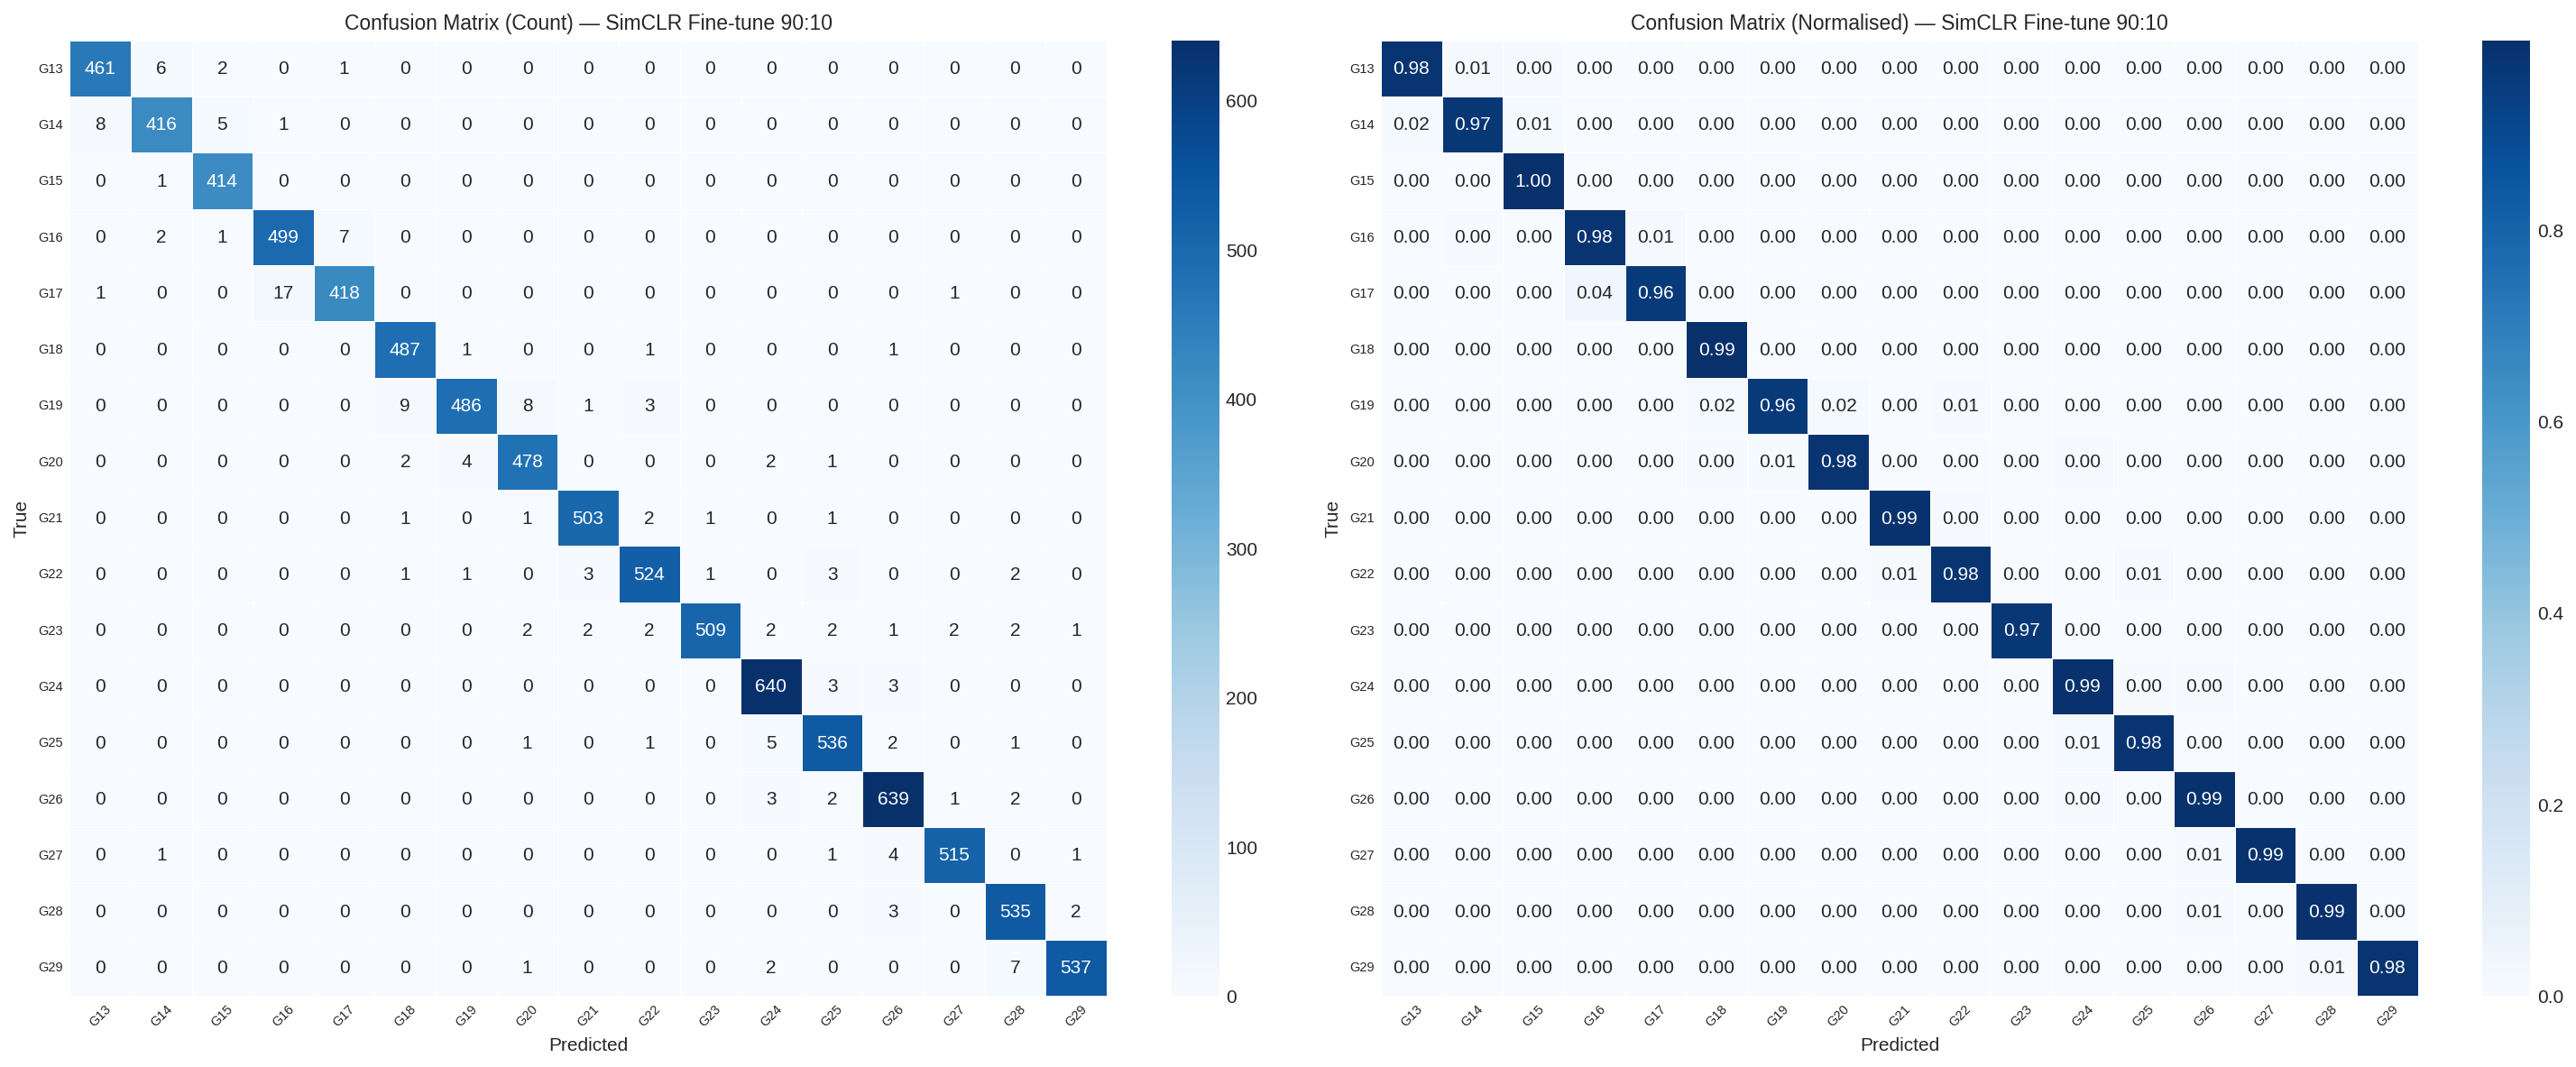


  LABEL EFFICIENCY


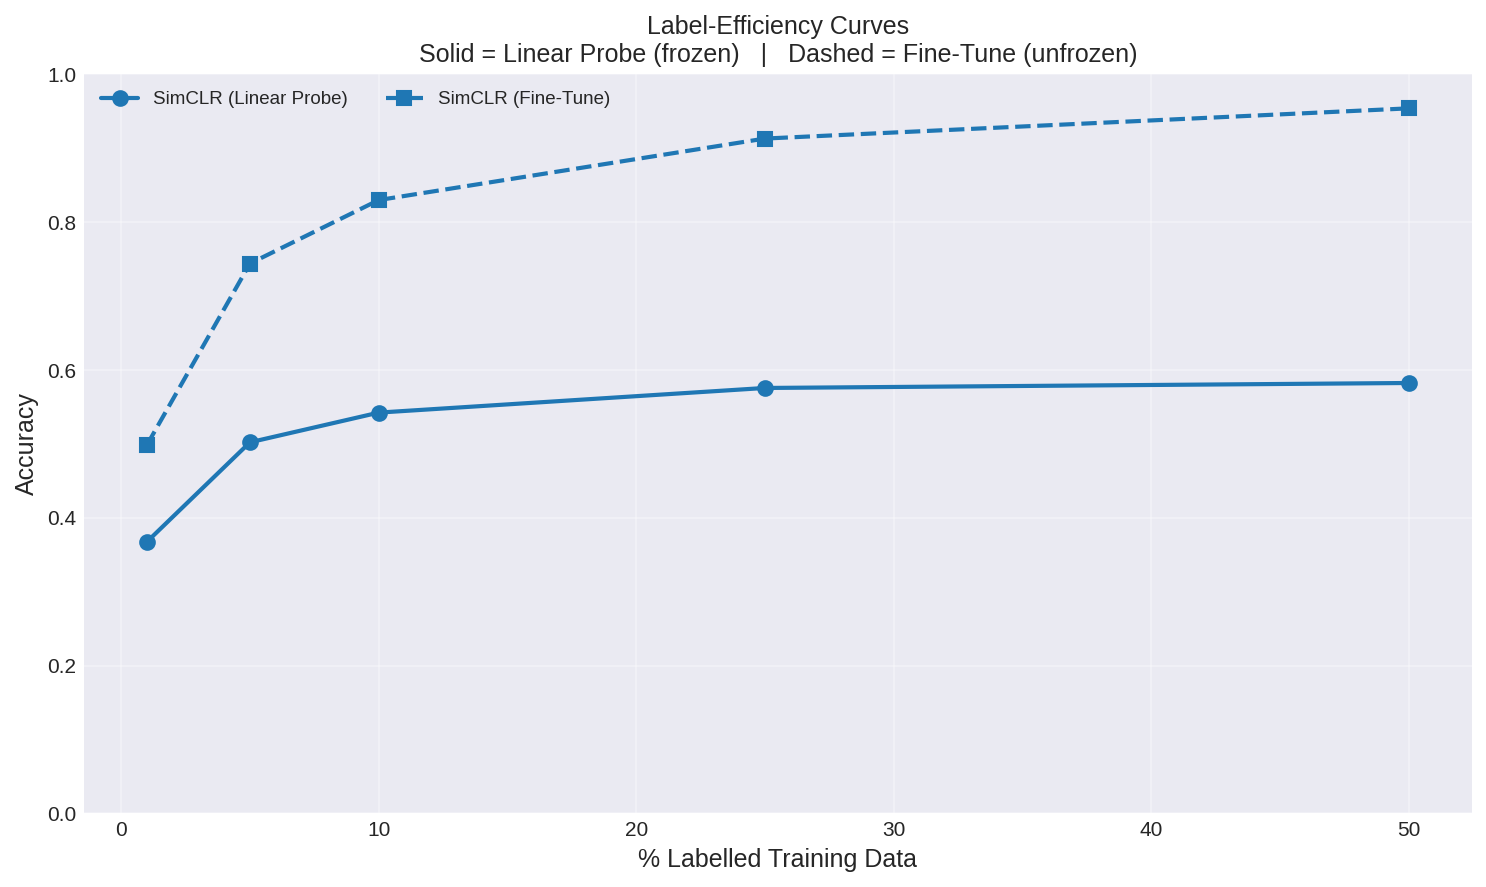


  PCA SIMCLR


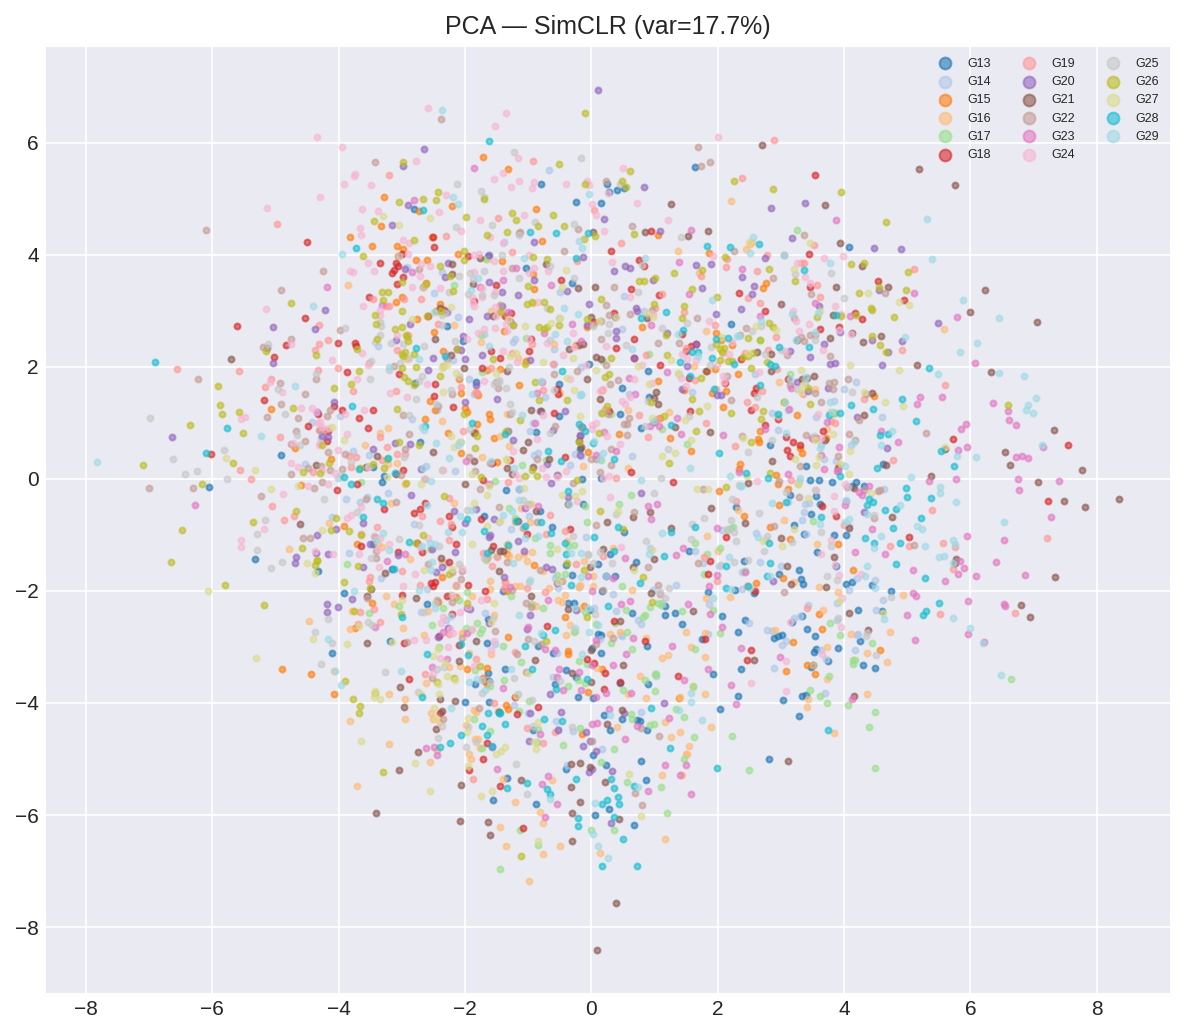


  ROC SIMCLR 90 10


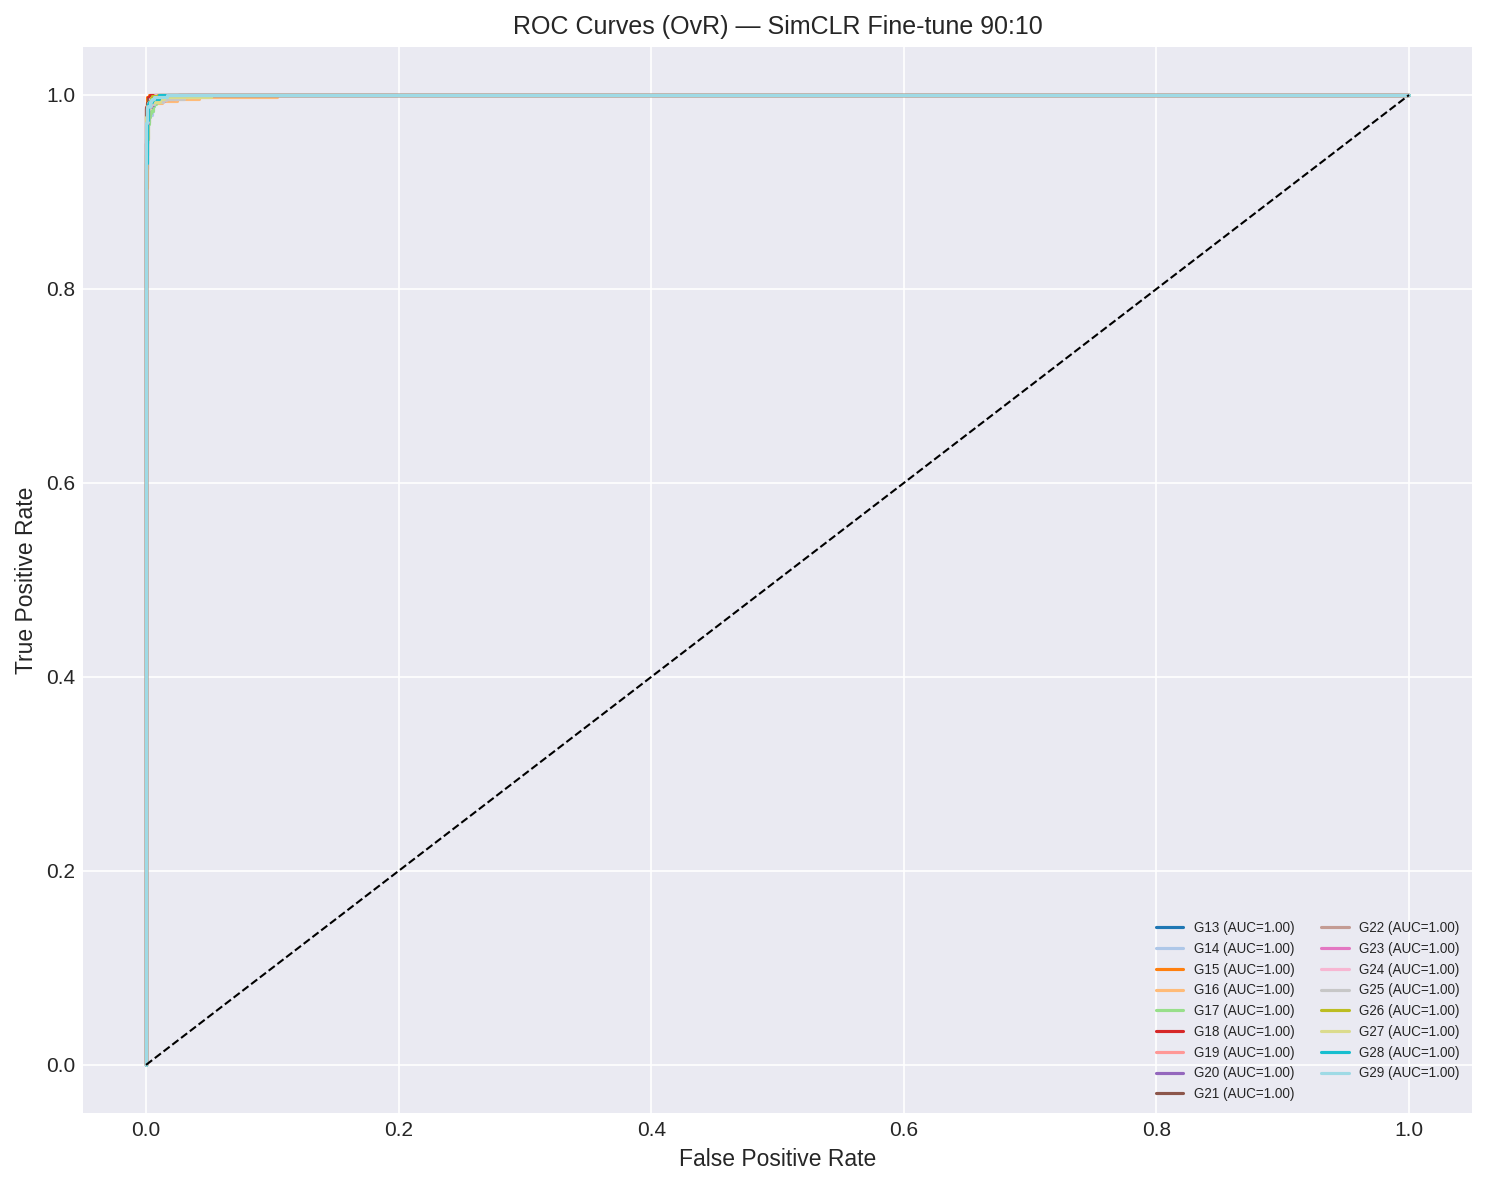


  SSL COMPARISON


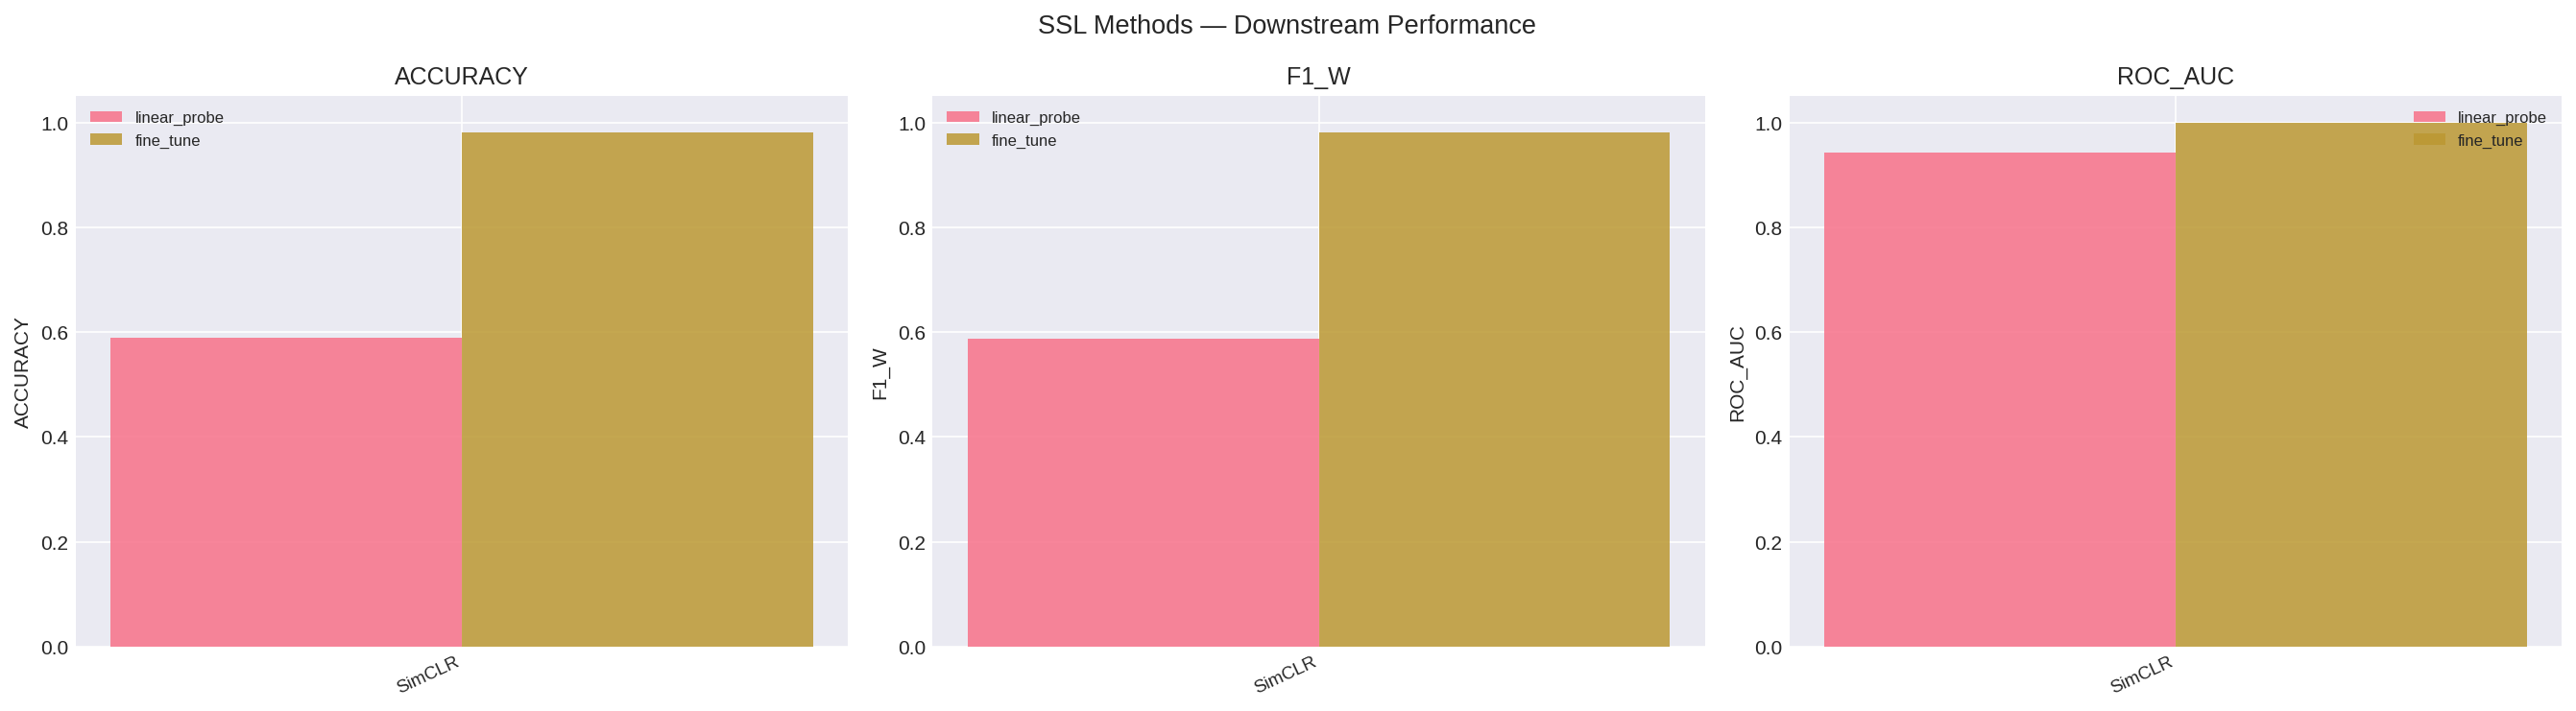


  SSL LOSS CURVES


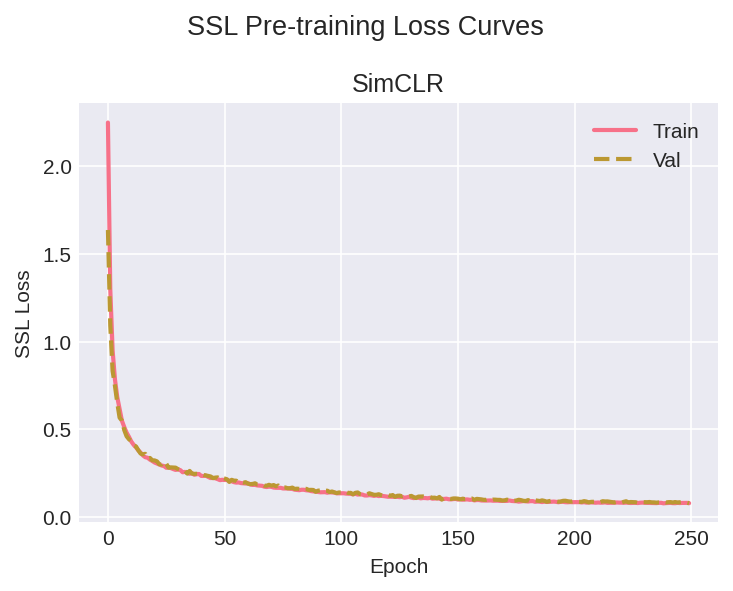


  TSNE SIMCLR


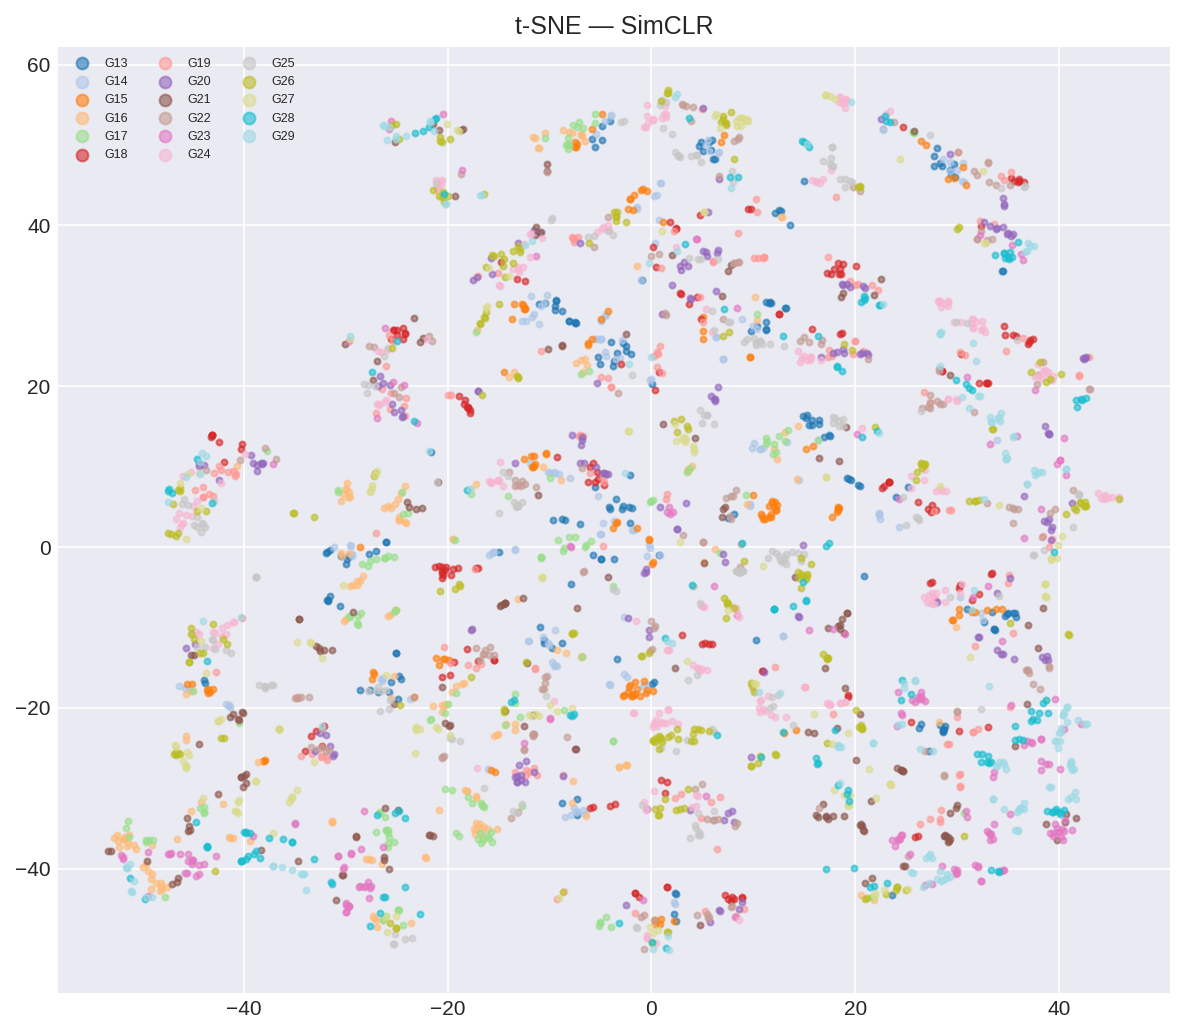


  UMAP SIMCLR


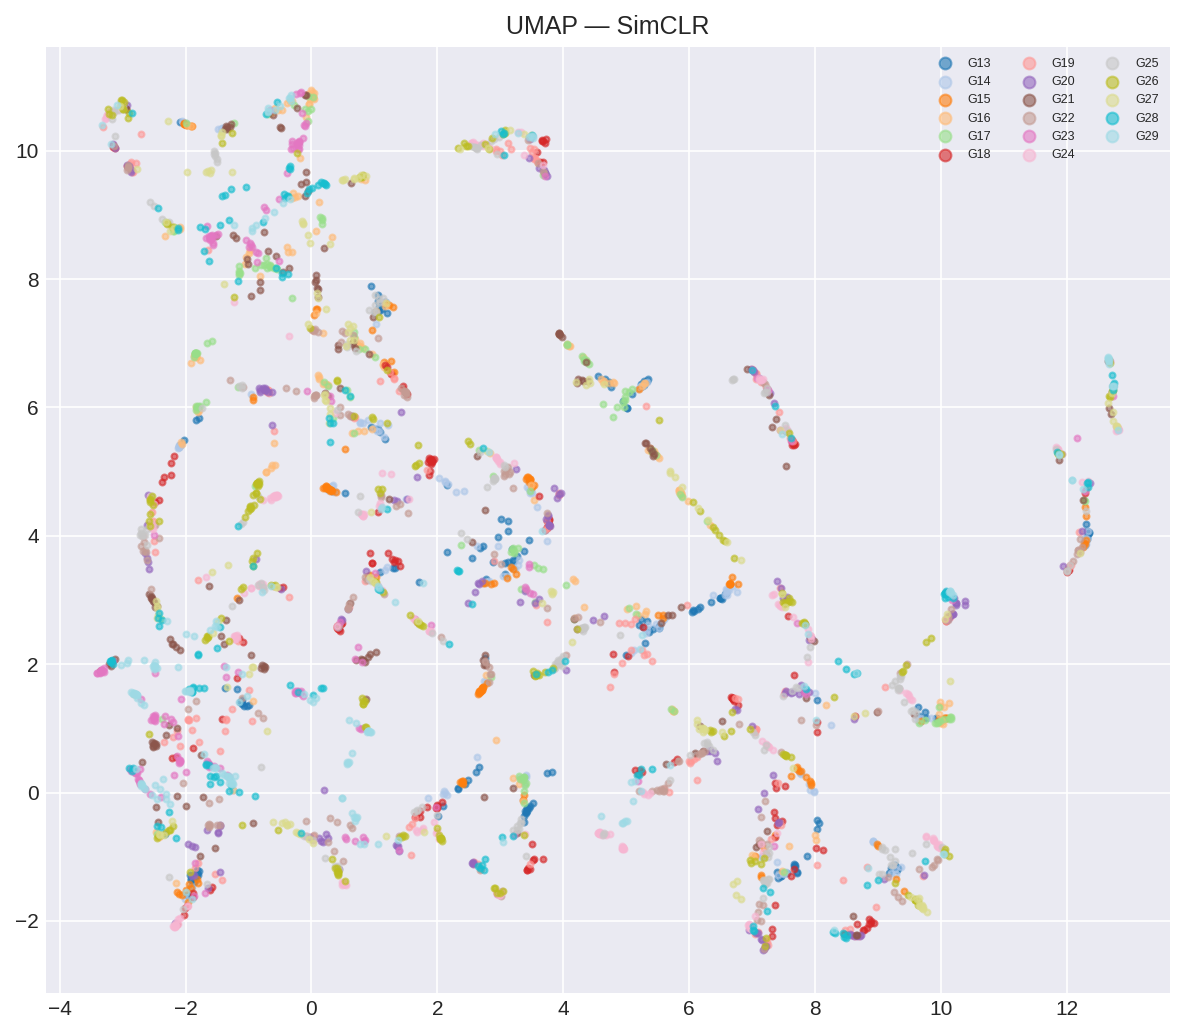

In [44]:
# Commented out IPython magic to ensure Python compatibility.
# %matplotlib inline
from IPython.display import Image, display

plot_dir = Path('/kaggle/working/plots_ssl')
all_pngs = sorted(plot_dir.glob('*.png'))

if not all_pngs:
    print("No plots found in", plot_dir)
else:
    print(f"Found {len(all_pngs)} plots\n")
    for fpath in all_pngs:
        print(f"\n{'='*60}")
        print(f"  {fpath.stem.upper().replace('_',' ')}")
        print(f"{'='*60}")
        display(Image(filename=str(fpath)))